## 特徵抓取與模型訓練

#### train


In [191]:
#!/usr/bin/env python3
import time, json
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, top_k_accuracy_score
import warnings
import pickle


warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
warnings.filterwarnings("ignore", category=DeprecationWarning)

class FPNode:
    """A node in an FP-tree."""
    def __init__(self, code=None):
        self.code = code
        self.count = 0
        self.children = {}

def main():
    results = {}
    # --- 1. 載入資料---
    t0 = time.time()
    # transfer t0 to utc -4 time
    print("Loading dataset...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t0 - 14400)))
    
    dataset = f'./data/dataset_{num_items}_items.csv'

    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    # txns = [[i for i in t if i != '-1' and i != ''] for t in txns]
    txns = [
        [item.strip() for item in txn
        if item.strip() and item.strip() != '-1']
        for txn in txns
    ]
    freq_counter = Counter(i for t in txns for i in t)
    unique_items = sorted(freq_counter)
    print(">> Unique items:", freq_counter, "count =", len(unique_items), flush=True)

    enc = LabelEncoder(); enc.fit(unique_items)
    N = len(txns)
    results['num_txns'] = N
    results['num_items'] = len(unique_items)
    results['preproc_time_s'] = time.time() - t0

    # --- 2. 特徵抽取 ---
    t1 = time.time()
    print("Extracting features...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t1 - 14400)))
    # real_root = type('FPNode', (), {'__init__': lambda s,code=None: setattr(s, 'children', {}) or setattr(s, 'count',0) or setattr(s,'code',code)})()
    real_root = FPNode()
    real_root.count = 0
    features, labels = [], []
    for txn in txns:
        seq = sorted(txn, key=lambda x:-freq_counter[x])
        codes = enc.transform(seq)
        node = real_root; node.count += 1; prefix = []
        for c in codes:
            # build feature vector
            pv = np.zeros(len(unique_items), int)
            for p in prefix: pv[p] = 1
            
            cc = np.zeros(len(unique_items), int)
            for ch, nd in node.children.items(): cc[ch] = nd.count
            
            pc, pl = node.count, len(prefix)
            
            item = enc.inverse_transform([c])[0]
            
            p_c = freq_counter[item]/N


            # p_p = freq_counter[prefix[-1]]/N if prefix else 1.0
            if prefix:
                last_code = prefix[-1]
                last_item = enc.inverse_transform([last_code])[0]
                p_p = freq_counter[last_item] / N
            else:
                p_p = 1.0
            
            edge_ct = node.children.get(c, type(node)()).count
            p_edge = edge_ct / N
            p_bound = p_c * p_p * p_edge

            feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
            features.append(feat); labels.append(c)

            # 插入節點
            if c not in node.children:
                nd = type(node)(code=c)
                nd.count = 0
                node.children[c] = nd
            node = node.children[c]; node.count += 1
            prefix.append(c)
            
            # if len(features) < 5:
            #     print("DBG:", item, p_c, p_p, p_edge, p_bound, flush=True)

    real_root.count = N
    X = np.array(features); y = np.array(labels)
    results['feature_count'] = X.shape[0]
    results['feature_time_s'] = time.time() - t1

    

    # --- 3. XGBoost 依商品拆分模型 ---
    t2 = time.time()
    print("Training models...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t2 - 14400)))
    tr, te = train_test_split(np.arange(len(y)), test_size=0.2, random_state=42)
    X_tr, y_tr = X[tr], y[tr]
    X_te, y_te = X[te], y[te]

    item_models = {}
    for code in range(len(unique_items)):
        yb = (y_tr == code).astype(int)
        if yb.sum() < 30: continue
        mdl = XGBClassifier(
           objective='binary:logistic',
           use_label_encoder=False, eval_metric='logloss',
           n_estimators=100, max_depth=6, learning_rate=0.1
        )
        mdl.fit(X_tr, yb)
        item_models[code] = mdl
    results['num_trained_models'] = len(item_models)
    results['train_time_s'] = time.time() - t2

    # --- 4. 預測 & 評估 ---
    t3 = time.time()
    print("Evaluating models...", time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(t3 - 14400)))
    proba = np.zeros((len(te), len(unique_items)))
    for i, idx in enumerate(te):
        xi = X[idx].reshape(1, -1)
        for c, m in item_models.items():
            proba[i, c] = m.predict_proba(xi)[0,1]
    acc1 = accuracy_score(y_te, proba.argmax(axis=1))
    # acc3 = top_k_accuracy_score(y_te, proba, k=3)
    results.update({
        'top1_acc': acc1,
        'top2_acc': top_k_accuracy_score(y_te, proba, k=2),
        'top3_acc': top_k_accuracy_score(y_te, proba, k=3),
        'top4_acc': top_k_accuracy_score(y_te, proba, k=4),
        'top5_acc': top_k_accuracy_score(y_te, proba, k=5),
    })
    results['eval_time_s'] = time.time() - t3

    # --- 5. 輸出結果 ---
    # 存 JSON
    with open('results_summary.json', 'w') as f:
        json.dump(results, f, indent=2)
    # Bash 輸出
    print("--- Results Summary ---")
    for k,v in results.items():
        print(f"{k:20s}: {v}")

    # --- 6. 保存模型與所需物件 ---
    
    print("Saving model artifacts...", flush=True)
    artifacts = {
        'models': item_models,
        'encoder': enc,
        'freq_counter': freq_counter,
        'real_root': real_root,
        'num_total_txns': N,
        'unique_items': unique_items
    }
    
    with open(f'fp_model_artifacts_{num_items}.pkl', 'wb') as f:
        pickle.dump(artifacts, f)
        
    print(f"Artifacts saved to fp_model_artifacts_{num_items}.pkl")

if __name__ == '__main__':
    
    num_items = ""  # 預設的項目數量
    main()

# 36
# Loading dataset... 2025-07-07 00:25:55
# >> Unique items: Counter({'1787079': 2492, '1787583': 2476, '21212': 1833, '470883': 1739, '998886': 1723, '22457': 1604, '435225': 1558, '470043': 1275, '477120': 1267, '435267': 1252, '466137': 1232, '1782459': 1205, '470106': 1188, '460551': 1170, '487263': 1170, '470631': 1148, '435288': 1136, '470022': 1107, '470064': 1087, '482181': 1076, '482160': 1073, '476679': 1065, '487389': 1065, '475986': 1061, '489258': 1049, '471849': 1039, '476637': 1009, '1732122': 979, '482853': 977, '463806': 907, '477267': 883, '1786029': 852, '1784937': 761, '1784370': 739, '316176': 658, '1776516': 601}) count = 36
# Extracting features... 2025-07-07 00:25:55
# Training models... 2025-07-07 00:26:04
# Evaluating models... 2025-07-07 00:26:27
# --- Results Summary ---
# num_txns            : 9677
# num_items           : 36
# preproc_time_s      : 0.22132539749145508
# feature_count       : 43456
# feature_time_s      : 9.559123039245605
# num_trained_models  : 36
# train_time_s        : 22.558951139450073
# top1_acc            : 0.5724804417855499
# top2_acc            : 0.7070869765301426
# top3_acc            : 0.7811780947998159
# top4_acc            : 0.8349056603773585
# top5_acc            : 0.866889093419236
# eval_time_s         : 222.93091249465942

# 12
# Loading dataset... 2025-07-11 00:47:10
# >> Unique items: Counter({'1787583': 2091, '1787079': 1830, '21212': 1639, '22457': 1444, '998886': 1416, '435225': 1276, '470883': 1266, '477120': 1025, '1782459': 967, '1786029': 720, '1784937': 651, '1776516': 537}) count = 12
# Extracting features... 2025-07-11 00:47:10
# Training models... 2025-07-11 00:47:13
# Evaluating models... 2025-07-11 00:47:16
# --- Results Summary ---
# num_txns            : 5238
# num_items           : 12
# preproc_time_s      : 0.08538961410522461
# feature_count       : 14862
# feature_time_s      : 2.426081418991089
# num_trained_models  : 12
# train_time_s        : 2.6865527629852295
# top1_acc            : 0.837874201143626
# top2_acc            : 0.9519004372687521
# top3_acc            : 0.9835183316515305
# top4_acc            : 0.9949545913218971
# top5_acc            : 0.9973091153716784
# eval_time_s         : 27.372808933258057
# Saving model artifacts...
# Artifacts saved to fp_model_artifacts_12.pkl

# 24
# Loading dataset... 2025-07-07 00:39:42
# >> Unique items: Counter({'1787079': 2452, '1787583': 2313, '21212': 1762, '998886': 1576, '22457': 1545, '435225': 1527, '470883': 1451, '470043': 1259, '435267': 1224, '470106': 1170, '466137': 1168, '477120': 1164, '460551': 1163, '470631': 1128, '435288': 1119, '487263': 1101, '1782459': 1096, '470022': 1081, '471849': 992, '482160': 971, '463806': 848, '1786029': 823, '1784937': 730, '1776516': 579}) count = 24
# Extracting features... 2025-07-07 00:39:42
# Training models... 2025-07-07 00:39:47
# Evaluating models... 2025-07-07 00:39:56
# --- Results Summary ---
# num_txns            : 7864
# num_items           : 24
# preproc_time_s      : 0.1052236557006836
# feature_count       : 30242
# feature_time_s      : 4.9420084953308105
# num_trained_models  : 24
# train_time_s        : 8.57649540901184
# top1_acc            : 0.659943792362374
# top2_acc            : 0.801124152752521
# top3_acc            : 0.8636138204661927
# top4_acc            : 0.9046123326169615
# top5_acc            : 0.9330467845924947
# eval_time_s         : 100.61779856681824
# Saving model artifacts...
# Artifacts saved to fp_model_artifacts.pkl


Loading dataset... 2025-07-13 17:22:40
>> Unique items: Counter({'Milk': 5526, 'Ghee': 5510, 'Coffee Powder': 5509, 'Yougurt': 5503, 'Bread': 5484, 'Sweet': 5483, 'Sugar': 5482, 'Butter': 5481, 'Cheese': 5476, 'Panner': 5444, 'Lassi': 5432, 'Tea Powder': 5383}) count = 12
Extracting features... 2025-07-13 17:22:40
Training models... 2025-07-13 17:22:53
Evaluating models... 2025-07-13 17:23:07
--- Results Summary ---
num_txns            : 12526
num_items           : 12
preproc_time_s      : 0.10580897331237793
feature_count       : 65713
feature_time_s      : 12.783533573150635
num_trained_models  : 12
train_time_s        : 14.320624828338623
top1_acc            : 0.9669786197976109
top2_acc            : 0.9918587841436506
top3_acc            : 0.9983261051510309
top4_acc            : 0.9991630525755155
top5_acc            : 0.9997717416115042
eval_time_s         : 134.15016746520996
Saving model artifacts...
Artifacts saved to fp_model_artifacts_.pkl


#### plot data

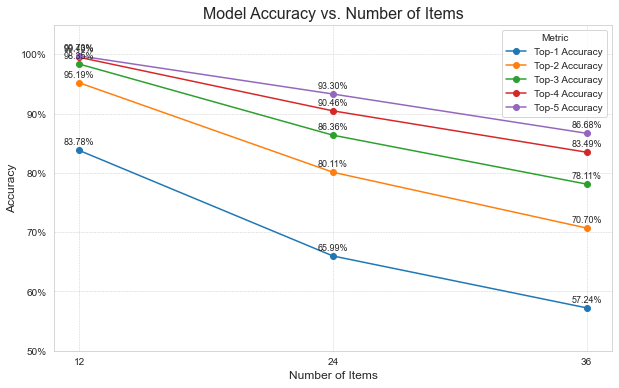

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style
sns.set_style("whitegrid")


data = {
    'num_items': [12, 24, 36, 0],  # 0 for the new experiment
    'Top-1 Accuracy': [0.8378, 0.6599, 0.5724, 0.9669],
    'Top-2 Accuracy': [0.9519, 0.8011, 0.7070, 0.9919],
    'Top-3 Accuracy': [0.9835, 0.8636, 0.7811, 0.9983],
    'Top-4 Accuracy': [0.9949, 0.9046, 0.8349, 0.9992],
    'Top-5 Accuracy': [0.9973, 0.9330, 0.8668, 0.9998],
}
df_acc = pd.DataFrame(data)

# --- Plotting (Corrected Method) ---
# Set 'num_items' as the index for plotting
df_acc_plot = df_acc.set_index('num_items')

# Use the DataFrame's plot method
ax = df_acc_plot.plot(kind='line', marker='o', figsize=(10, 6))

# Add value labels to each point by iterating through the lines
for line in ax.get_lines():
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x, y + 0.01, f'{y:.2%}', ha='center', fontsize=9)

# --- Formatting ---
plt.title('Model Accuracy vs. Number of Items', fontsize=16)
plt.xlabel('Number of Items', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(df_acc['num_items']) # Ensure x-axis ticks are exactly at 12, 24, 36
plt.ylim(0.5, 1.05) # Set y-axis limits for better visibility
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format)) # Format y-axis as percentage
plt.legend(title='Metric')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Show the plot
plt.show()

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


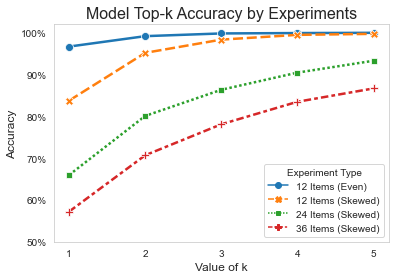

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Set a professional plot style
sns.set_style("whitegrid")

# --- Data Preparation (Restructured for new plot) ---
# We create a "long-form" DataFrame suitable for seaborn
data = {
    # The 'k' value for the x-axis
    'k': [1, 2, 3, 4, 5] * 4,
    # The accuracy values for each experiment
    'Accuracy': [
        # 1. Data for '12 Items (Even)' experiment
        0.9669, 0.9918, 0.9983, 0.9992, 0.9998,
        # 2. Data for '12 Items (Skewed)' experiment
        0.8378, 0.9519, 0.9835, 0.9949, 0.9973,
        # 3. Data for '24 Items' experiment
        0.6599, 0.8011, 0.8636, 0.9046, 0.9330,
        # 4. Data for '36 Items' experiment
        0.5724, 0.7070, 0.7811, 0.8349, 0.8668
    ],
    # A label for each experiment, used for coloring the lines
    'Experiment':
        ['12 Items (Even)'] * 5 +
        ['12 Items (Skewed)'] * 5 +
        ['24 Items (Skewed)'] * 5 +
        ['36 Items (Skewed)'] * 5
}
df_long = pd.DataFrame(data)

# --- Plotting ---
# plt.figure(figsize=(11, 7))

# Use seaborn.lineplot which is ideal for this data structure
ax = sns.lineplot(
    data=df_long,
    x='k',
    y='Accuracy',
    hue='Experiment', # Color lines based on the experiment
    style='Experiment', # Use different line styles for clarity
    markers=True,       # Add markers to each data point
    markersize=8,
    linewidth=2.5
)

# --- Formatting ---
plt.title('Model Top-k Accuracy by Experiments', fontsize=16)
plt.xlabel('Value of k', fontsize=12) # k in Top-k
plt.ylabel('Accuracy', fontsize=12)

# Set x-axis ticks to be integers (1, 2, 3, 4, 5)
plt.xticks(ticks=[1, 2, 3, 4, 5])

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.ylim(0.5, 1.02) # Adjust y-axis for better visibility

plt.legend(title='Experiment Type')
plt.grid(True, which='both', linestyle='', linewidth=0.5)

# Show the plot
plt.show()

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


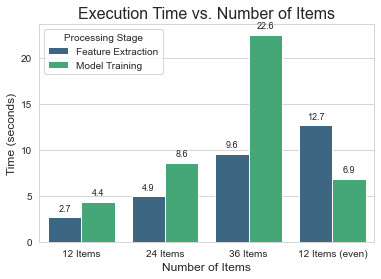

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# --- Data Preparation ---
# Using the same three experiments with English labels
time_data = {
    'Number of Items': ["12 Items", "24 Items", "36 Items", "12 Items (even)"],
    'Feature Extraction': [2.68, 4.94, 9.55, 12.67],
    'Model Training': [4.37, 8.57, 22.55, 6.86]#,
    # 'Model Evaluation': [30.32, 100.61, 222.93, 115.64]
}


df_time = pd.DataFrame(time_data)

# Melt the dataframe to prepare for grouped bar plot
df_time_melted = df_time.melt(id_vars='Number of Items', var_name='Processing Stage', value_name='Time (seconds)')

# --- Plotting ---
# plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_time_melted, x='Number of Items', y='Time (seconds)', hue='Processing Stage', palette='viridis')

# --- Formatting ---
plt.title('Execution Time vs. Number of Items', fontsize=16)
plt.xlabel('Number of Items', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.legend(title='Processing Stage')

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

# Show the plot
plt.show()

In [ ]:
# --- Data Preparation ---
# Data from your three comparable experiments (12, 24, 36 items)
# preproc_time_s      : 0.32550501823425293
# feature_count       : 65713
# feature_time_s      : 12.67265009880066
# num_trained_models  : 12
# train_time_s        : 6.859451532363892
# top1_acc            : 0.9669786197976109
# top2_acc            : 0.9918587841436506
# top3_acc            : 0.9983261051510309
# top4_acc            : 0.9991630525755155
# top5_acc            : 0.9997717416115042
# eval_time_s         : 115.64450407028198

## function
不設max_length，基於上一層結果 決定要不要算下一層

#### function

In [14]:
import numpy as np
from collections import Counter
import pandas as pd
import warnings
import time
import pickle
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

class FPNode:
    """A node in an FP-tree."""
    def __init__(self, code=None):
        self.code = code
        self.count = 0
        self.children = {}  
        
def generate_features_for_prefix(prefix_codes, artifacts):
    """
    為給定的前綴生成預測下一步驟所需的特徵。
    這個函數一次性準備好上下文，而不是為每個可能的子節點重複計算。
    """
    enc = artifacts['encoder']
    real_root = artifacts['real_root']
    freq_counter = artifacts['freq_counter']
    N = artifacts['num_total_txns']
    num_unique_items = len(artifacts['unique_items'])

    node = real_root
    # 根據 prefix_codes 遍歷樹，找到當前節點
    for code in prefix_codes:
        if code in node.children:
            node = node.children[code]
        else:
            # 如果路徑在訓練時的樹中不存在，則無法繼續生成
            return None, None 

    # --- 準備特徵 ---
    # 1. 前綴向量 (pv)
    pv = np.zeros(num_unique_items, int)
    for p in prefix_codes:
        pv[p] = 1

    # 2. 子節點計數向量 (cc)
    cc = np.zeros(num_unique_items, int)
    for ch, nd in node.children.items():
        cc[ch] = nd.count

    # 3. 父節點計數 (pc) 和 前綴長度 (pl)
    pc = node.count
    pl = len(prefix_codes)
    
    # 4. 前綴最後一個項目的機率 P(p)
    if prefix_codes:
        last_code = prefix_codes[-1]
        last_item = enc.inverse_transform([last_code])[0]
        p_p = freq_counter[last_item] / N
    else:
        # 如果是空前綴，父機率設為1.0
        p_p = 1.0

    base_features = (pv, cc, pc, pl, p_p)
    return base_features, node


def generate_one_step_expansion(base_pattern_codes, artifacts, top_k=None, proba_threshold=0.01):
    """
    給定一個已知的頻繁樣式，使用 ML 模型預測最可能的 k 個擴展項。
    """

    # 計算運行時間
    start_time = time.time()


    # 1. 為基礎樣式生成特徵
    base_features, node = generate_features_for_prefix(base_pattern_codes, artifacts)
    if base_features is None:
        return [], 0.0 # 如果基礎樣式是死路，則無法擴展

    pv, cc, pc, pl, p_p = base_features
    
    # 2. 預測所有可能的下一步的機率
    predictions = []
    item_models = artifacts['models']
    enc = artifacts['encoder']
    freq_counter = artifacts['freq_counter']
    N = artifacts['num_total_txns']
    num_unique_items = len(artifacts['unique_items'])

    for c in range(num_unique_items):
        if c in base_pattern_codes or c not in item_models:
            continue

        item = enc.inverse_transform([c])[0]
        p_c = freq_counter[item] / N if N > 0 else 0
        edge_ct = node.children.get(c, FPNode()).count
        p_edge = edge_ct / N if N > 0 else 0
        p_bound = p_c * p_p * p_edge
        
        feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]]).reshape(1, -1)
        
        proba = item_models[c].predict_proba(feat)[0, 1] 
        # if proba > 1e-5: # 避免 log(0)
        # if proba > 0.01:
        if proba > proba_threshold:
            predictions.append((proba, c))


    # 3. 排序
    predictions.sort(key=lambda x: x[0], reverse=True)
    
    # 4. 構建新的候選樣式
    new_candidates = []
    
    # 選出 top_k 個最佳擴展
    if top_k is not None:
        predictions = predictions[:top_k]

    for proba, next_code in predictions:
        new_pattern = base_pattern_codes + [next_code]
        new_candidates.append(new_pattern)
        
    # 計算運行時間
    end_time = time.time()
    elapsed_time = end_time - start_time
    return new_candidates, elapsed_time


def validate_patterns_with_artifacts(candidate_patterns, artifacts, min_support_threshold, dataset_prct = 0.8, txns_train=None):
    """
    驗證候選樣式的真實支持度，並計算詳細統計數據
    """
    # print("\n--- Validating Candidate Patterns ---")
    start_time = time.time()
    # 從 artifacts 中獲取所需物件，避免重複載入
    enc = artifacts['encoder']

    total_train_txns = len(txns_train)
    # 根據支持度比例計算出絕對計數的門檻
    min_support_count_threshold = total_train_txns * min_support_threshold

    # missing_pattern_1 = frozenset(['Sweet', 'Sugar', 'Butter'])
    # missing_pattern_2 = frozenset(['Sweet', 'Panner', 'Lassi'])

    frequent_patterns = {}
    support_not_select = []
    support_select = []

    # 將候選樣式從 tuple 轉回 list of codes，如果需要的話
    candidate_patterns_list = [list(p) for p in candidate_patterns]

    for pattern_codes in candidate_patterns_list:
        # 將 code 轉回 item name
        pattern_set = set(enc.inverse_transform(pattern_codes))
        
        support_count = sum(1 for txn_set in txns_train if pattern_set.issubset(txn_set))
        
        support_ratio = support_count / total_train_txns if total_train_txns > 0 else 0

         # --- 找消失樣式 ---
        # if pattern_set == missing_pattern_1 or pattern_set == missing_pattern_2:
        #     print("\n" + "*"*20)
        #     print(f"DEBUGGING MISSING PATTERN: {pattern_set}")
        #     print(f"  - Exact Support Count: {support_count}")
        #     print(f"  - Required Count Threshold: {min_support_count_threshold:.2f}")
        #     print(f"  - Is Frequent? {support_count >= min_support_count_threshold}")
        #     print("*"*20)
        # --- ---
        
        # 使用正確的計數門檻進行比較
        if support_count >= min_support_count_threshold:
            frequent_patterns[tuple(pattern_codes)] = support_ratio
            support_select.append(support_ratio)
        else:
            support_not_select.append(support_ratio)

    end_time = time.time()
    validation_time = end_time - start_time
    # --- 統計分析部分  ---
    print(f"Found {len(frequent_patterns)} frequent patterns with support >= {min_support_threshold:.2f} in {total_train_txns} transactions.")
    
    if candidate_patterns:
        print(f"Validation ratio: {len(frequent_patterns) / len(candidate_patterns):.2%}: {len(frequent_patterns)}/{len(candidate_patterns)}")

    # 各長度通過驗證的比例
    lengths = [len(p) for p in candidate_patterns_list]
    length_counter = Counter(lengths)
    # print("\n--- Length-wise Validation Ratios ---")
    for length, count in sorted(length_counter.items()):
        # frequent_patterns 的 key 是 tuple of codes
        valid_count = sum(1 for p in frequent_patterns.keys() if len(p) == length)
        ratio = valid_count / count if count > 0 else 0
        # print(f"Length {length}: {valid_count}/{count} = {ratio:.2%}")
    
    # --- 統計支持度 ---
    # the average support of the patterns not selected
    if support_not_select:
        avg_support_not_select = sum(support_not_select) / len(support_not_select)
        # print(f"Average support of patterns not selected: {avg_support_not_select:.4f}")
        # the highest support of the patterns not selected
        max_support_not_select = max(support_not_select)
        # print(f"Highest support of patterns not selected: {max_support_not_select:.4f}")
        # the lowest support of the patterns not selected
        min_support_not_select = min(support_not_select)
        # print(f"Lowest support of patterns not selected: {min_support_not_select:.4f}")
        # median support of the patterns not selected
        median_support_not_select = np.median(support_not_select)
        # print(f"Median support of patterns not selected: {median_support_not_select:.4f}")

        # print(f"Total support not selected: {len(support_not_select)} patterns")
        print(f"not selected {len(support_not_select)} patterns support: avg={avg_support_not_select:.4f}, max={max_support_not_select:.4f}, min={min_support_not_select:.4f}, median={median_support_not_select:.4f}")
    
    if support_select:
        avg_support_select = sum(support_select) / len(support_select)
        # print(f"Average support of selected patterns: {avg_support_select:.4f}")
        # the highest support of the patterns selected
        max_support_select = max(support_select)
        # print(f"Highest support of selected patterns: {max_support_select:.4f}")
        # the lowest support of the patterns selected
        min_support_select = min(support_select)
        # print(f"Lowest support of selected patterns: {min_support_select:.4f}")
        # median support of the patterns selected
        median_support_select = np.median(support_select)
        # print(f"Median support of selected patterns: {median_support_select:.4f}")

        print(f"selected {len(support_select)} patterns support: avg={avg_support_select:.4f}, max={max_support_select:.4f}, min={min_support_select:.4f}, median={median_support_select:.4f}")
        # print(f"Total support selected: {len(support_select)} patterns")
    
    return frequent_patterns, validation_time


def apriori_candidate_comparator(freq_itemsets_prev_level_keys, artifacts):
    """
    從 L(k-1) 生成 L(k) 的候選集，使用 Apriori 的 F(k-1) x F(k-1) 方法。
    freq_itemsets_prev_level_keys: 一個包含元組的迭代器/列表，代表上一層的頻繁樣式。
    """

    # 將 code-based 的元轉換為 name-based 的 frozenset
    encoder = artifacts['encoder']
    itemsets_L_minus_1 = [frozenset(encoder.inverse_transform(list(p))) for p in freq_itemsets_prev_level_keys]

    # 避免重複
    candidates = set()

    k = len(next(iter(itemsets_L_minus_1))) + 1 # k 是我們要生成的候選集的長度

    # 遍歷所有可能的對偶
    itemsets_list = list(itemsets_L_minus_1)

    for i in range(len(itemsets_list)):
        for j in range(i + 1, len(itemsets_list)):

            p1 = itemsets_list[i]
            p2 = itemsets_list[j]
            
            # 1. Self-joining step: 如果它們共享 k-2 個項目，則可以合併
            intersection = p1.intersection(p2)

            if len(intersection) == k - 2:
                candidate = p1.union(p2)
                
            # 2. Pruning step: 檢查該候選的所有 k-1 子集是否都在上一層的頻繁集中
                is_valid = True
                for item in candidate:
                    subset = candidate.difference({item})
                    if subset not in itemsets_L_minus_1:
                        is_valid = False
                        break

                if is_valid:
                    candidates.add(candidate)

    return candidates

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


##### 增加效率 降低召回率
候選集不保留 不同順序組合

In [63]:
# 減少候選集
def run_hybrid_generation(artifacts, min_support_threshold=0.01, dataset_prct = 0.8, top_k_expansion=None, proba_threshold = 0.01, dataset='./data/dataset_36_items.csv'):
    """
    **[主流程函數]**
    執行逐層生成的混合式頻繁樣式探勘。
    """
    # # 重新載入原始交易數據的訓練集
    # # 在優化版本中，這一步可以移到主流程，避免在迴圈中重複讀取檔案
    # df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    # txns = df[0].str.split(',').tolist()
    # txns = [
    #     {item.strip() for item in txn if item.strip() and item.strip() != '-1'}
    #     for txn in txns
    # ]
    # # 只用訓練集 0.8 的交易數據
    # txns_train = txns[:int(len(txns) * dataset_prct)]
    txns_train = dataset

    # --- 第 1 層：從單一商品開始 ---
    total_generate_time = 0.0
    total_validation_time = 0.0
    print("this version does NOT keep same patterns in different orders")
    print("--- Level 1: Validating single items --- (minimum support threshold = {:.2f})".format(min_support_threshold))
    all_single_items = [[code] for code in range(len(artifacts['unique_items']))]
    # 驗證所有長度為 1 的商品，得到 L1 頻繁集
    
    last_validated_patterns, val_time_level1 = validate_patterns_with_artifacts(all_single_items, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
    total_validation_time += val_time_level1
    
    all_frequent_patterns = last_validated_patterns.copy()
    # print(f"Found {len(last_validated_patterns)} frequent items at Level 1.")

    current_length = 2
    # len_apriori_candidates = 0 # 儲存每層的 Apriori 候選集
    len_ml_candidates = 0 # 儲存每層的 ML 候選集
    # --- 逐層生成迴圈 ---
    while last_validated_patterns: # 只要上一層還有頻繁樣式，就繼續
        print(f"\n--- Level {current_length}: Generating candidates from {len(last_validated_patterns)} frequent patterns ---")
        # # --- 新增：Apriori 候選集生成 ---
        # apriori_candidate = apriori_candidate_comparator(last_validated_patterns.keys(), artifacts)
        # print(f"Apriori method would have generated: {len(apriori_candidate)} candidates.")
        # len_apriori_candidates += len(apriori_candidate)
        
        # 1: 為當前層級的所有可能擴展，生成特徵
        features_to_predict = [] # 儲存 (base_pattern_codes, next_code, feat)
        start_generate_time = time.time()

        for pattern_codes_tuple in last_validated_patterns.keys():

            base_pattern_codes = list(pattern_codes_tuple)

            # 按照出現頻率排序
            # base_pattern_codes.sort(
            #     key=lambda code: artifacts['freq_counter'].get(artifacts['encoder'].inverse_transform([code])[0], 0), 
            #     reverse=True
            # )

            base_features, node = generate_features_for_prefix(base_pattern_codes, artifacts)
            if base_features is None: continue

            pv, cc, pc, pl, p_p = base_features
            
            for c in range(len(artifacts['unique_items'])):
                if c in base_pattern_codes or c not in artifacts['models']:
                    continue
                
                # 完成特徵向量
                item = artifacts['encoder'].inverse_transform([c])[0]
                p_c = artifacts['freq_counter'][item] / artifacts['num_total_txns']
                edge_ct = node.children.get(c, FPNode()).count
                p_edge = edge_ct / artifacts['num_total_txns']
                p_bound = p_c * p_p * p_edge
                
                feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
                features_to_predict.append({'base': pattern_codes_tuple, 'next': c, 'feature': feat})

        if not features_to_predict:
            print("No new candidates can be generated.")
            break
            
        print(f"Generated {len(features_to_predict)} feature vectors for Level {current_length}.")
        
        # 2: 批次推論
        all_features_np = np.vstack([f['feature'] for f in features_to_predict])
        
        # 取得所有模型的預測機率
        # key: item_code (c), value: array of probabilities for that item
        all_probas = {}
        for c, model in artifacts['models'].items():
            # 對於 item 'c' 的模型，批次預測所有特徵向量會成為 'c' 的機率
            probas_for_c = model.predict_proba(all_features_np)[:, 1]
            all_probas[c] = probas_for_c
            
        # # 3: 根據機率建立候選集

        # 3.1: 收集並按父樣式分組所有預測結果
        from collections import defaultdict
        predictions_by_base = defaultdict(list)
        for i, f_info in enumerate(features_to_predict):
            base_pattern = f_info['base']
            next_code = f_info['next']
            proba = all_probas[next_code][i]
            predictions_by_base[base_pattern].append((proba, next_code))

        # 3.2: 對每一組預測進行排序和 top-k 篩選
        next_level_candidates_list = []
        # proba_threshold = 0.01 #1e-5 #0.01 # 可調整閾值
        print(f"top-k_expansion: {top_k_expansion}, proba_threshold: {proba_threshold:.2f}")
        #     if proba > proba_threshold:
        #     # if proba > 0.01:
        #         # 保留原始順序，而不是排序後再儲存
        #         new_pattern = list(f_info['base']) + [next_code]
        #         next_level_candidates_list.append(tuple(new_pattern)) # 直接儲存 tuple(new_pattern)
        # #         next_level_candidates_list.append(tuple(sorted(new_pattern))) # 去重複
        for base_pattern, predictions in predictions_by_base.items():
            # 按機率從高到低排序
            predictions.sort(key=lambda x: x[0], reverse=True)
            
            # 如果 top_k_expansion 被指定，則只取前 k 個
            if top_k_expansion is not None:
                predictions = predictions[:top_k_expansion]
  
            # 建立新的候選樣式
            for proba, next_code in predictions:

                if proba > proba_threshold: # if proba > 0.01:
                # 保留原始順序，而不是排序後再儲存
                    # new_pattern = list(f_info['base']) + [next_code]
                    new_pattern = list(base_pattern) + [next_code]
                    next_level_candidates_list.append(tuple(new_pattern)) # 直接儲存 tuple(new_pattern)
            #         next_level_candidates_list.append(tuple(sorted(new_pattern))) # 去重複

        ###
        end_generate_time = time.time()
        generate_time = end_generate_time - start_generate_time
        total_generate_time += generate_time
        # 此時 next_level_candidates_list 中可能包含 ('A','B') 和 ('B','A')

        # # 使用 set 去除重複的候選集
        # # next_level_candidates_set = set(next_level_candidates_list)
        print(f"Generated {len(next_level_candidates_list)} candidates for Level {current_length} with probability > {proba_threshold:.2f}.")
        # # if not next_level_candidates_set:
        if not next_level_candidates_list:
            print("No new candidates passed the probability threshold.")
            break

        # 3.3 
        # --- 新增：Apriori 剪枝步驟 ---

        # 如果不使用 Apriori 剪枝，則直接使用 next_level_candidates_list
        # pruned_ml_candidates = next_level_candidates_list

        from itertools import combinations
        
        # 將上一層的頻繁樣式轉為 name-based frozenset
        frequent_km1_sets = {frozenset(artifacts['encoder'].inverse_transform(list(p))) for p in last_validated_patterns.keys()}
        k = current_length # 當前要生成的樣式長度

        pruned_ml_candidates = []
        for cand_tuple in next_level_candidates_list:
            cand_codes = list(cand_tuple)
            # 將候選樣式也轉為 name-based frozenset
            cand_names_set = frozenset(artifacts['encoder'].inverse_transform(cand_codes))
            
            is_valid = True
            if len(cand_names_set) == k:
                # 檢查所有 k-1 子集是否都在上一層的頻繁集中
                for subset in combinations(cand_names_set, k - 1):
                    if frozenset(subset) not in frequent_km1_sets:
                        is_valid = False
                        break
            
            if is_valid:
                pruned_ml_candidates.append(cand_tuple)
        
        print(f"After Apriori pruning, {len(pruned_ml_candidates)} candidates remain.")

        
        
        
        
        # 步驟 4: 驗證 (現在 validate_patterns 函式需要接收 txns_train 作為參數)
        # validated_patterns, val_time = validate_patterns_with_artifacts(
        #     list(next_level_candidates_set), artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train
        # )
        # validated_patterns, val_time = validate_patterns_with_artifacts(
        #     next_level_candidates_list, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
        # unique_candidates_for_validation = {tuple(sorted(p)) for p in next_level_candidates_list}
        
        # 將剪枝後的候選集送去驗證
        unique_candidates_for_validation = {tuple(sorted(p)) for p in pruned_ml_candidates}

        print(f"Generated {len(next_level_candidates_list)} ordered candidates, "
            f"which resulted in {len(unique_candidates_for_validation)} unique sets for validation.")
        len_ml_candidates += len(unique_candidates_for_validation)
        # 將去重後的集合傳遞給驗證函式
        validated_patterns, val_time = validate_patterns_with_artifacts(
            list(unique_candidates_for_validation), 
            artifacts, 
            min_support_threshold, 
            dataset_prct=dataset_prct,
            txns_train=txns_train
        )
        
        ####
        total_validation_time += val_time
        print(f"Validation completed for Level {current_length} in {val_time:.2f} seconds.")

        if not validated_patterns:
            print(f"No frequent patterns found at Level {current_length}. Halting generation.")
            break
        # print(f"Validated {len(validated_patterns)} frequent patterns at Level {current_length}.")
              
        # 3. 準備下一輪
        all_frequent_patterns.update(validated_patterns)
        last_validated_patterns = validated_patterns
        current_length += 1
        
    return all_frequent_patterns, total_generate_time, total_validation_time, len_ml_candidates



c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


##### 保留不同順序的組合 變慢但召回率高

In [16]:
## 會保留不同順序的組合

def run_hybrid_generations(artifacts, min_support_threshold=0.01, dataset_prct = 0.8, top_k_expansion=None, dataset='./data/dataset_36_items.csv'):
# def run_hybrid_generation(artifacts, min_support_threshold=0.01, dataset_prct = 0.8, top_k_expansion=None):
    """
    **[主流程函數]**
    執行逐層生成的混合式頻繁樣式探勘。
    """
    # 重新載入原始交易數據的訓練集
    # 在優化版本中，這一步可以移到主流程，避免在迴圈中重複讀取檔案
    df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df[0].str.split(',').tolist()
    txns = [
        {item.strip() for item in txn if item.strip() and item.strip() != '-1'}
        for txn in txns
    ]
    # 只用訓練集 0.8 的交易數據
    txns_train = txns[:int(len(txns) * dataset_prct)]

    # --- 第 1 層：從單一商品開始 ---
    total_generate_time = 0.0
    total_validation_time = 0.0

    print("--- Level 1: Validating single items --- (minimum support threshold = {:.2f})".format(min_support_threshold))
    all_single_items = [[code] for code in range(len(artifacts['unique_items']))]
    # 驗證所有長度為 1 的商品，得到 L1 頻繁集
    
    last_validated_patterns, val_time_level1 = validate_patterns_with_artifacts(all_single_items, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
    total_validation_time += val_time_level1
    
    all_frequent_patterns = last_validated_patterns.copy()
    # print(f"Found {len(last_validated_patterns)} frequent items at Level 1.")

    current_length = 2
    
    # --- 逐層生成迴圈 ---
    while last_validated_patterns: # 只要上一層還有頻繁樣式，就繼續
        print(f"\n--- Level {current_length}: Generating candidates from {len(last_validated_patterns)} frequent patterns ---")
        
        # 1. 生成候選集
        # next_level_candidates = set()
        # 從 set 改為 list，不去除重複
        next_level_candidates_list = []
        # 從上一層的所有頻繁樣式出發
        for pattern_codes_tuple in last_validated_patterns.keys():
            
            # 將 pattern_codes_tuple 轉為 list 並排序，確保順序一致性
            # 這樣可以避免在生成候選樣式時出現順序不一致的情況
            pattern_codes_list = list(pattern_codes_tuple)
            pattern_codes_list.sort(key=lambda code: artifacts['freq_counter'][artifacts['encoder'].inverse_transform([code])[0]], reverse=True)

            # 使用 ML 模型進行單步擴展
            new_candidates, generate_time = generate_one_step_expansion(list(pattern_codes_tuple), artifacts, top_k=top_k_expansion)
            # for cand in new_candidates:
            #     # 將候選樣式以標準型(排序後的tuple)存入set，自動去重
            #     next_level_candidates.add(tuple(sorted(cand)))
            next_level_candidates_list.extend(new_candidates)
            total_generate_time += generate_time
        print(f"Generated {len(next_level_candidates_list)} candidates for Level {current_length} in {total_generate_time:.2f} seconds.")

        # if not next_level_candidates:
        if not next_level_candidates_list:
            print("No new candidates were generated.")
            break
        # print(f"Generated {len(next_level_candidates)} unique candidates for Level {current_length}.")

        # 2. 驗證新生成的候選集
        # validated_patterns = validate_patterns_with_artifacts(list(next_level_candidates), artifacts, min_support_threshold)
        validated_patterns, val_time = validate_patterns_with_artifacts(next_level_candidates_list, artifacts, min_support_threshold, dataset_prct=dataset_prct, txns_train=txns_train)
        
        total_validation_time += val_time
        print(f"Validation completed for Level {current_length} in {val_time:.2f} seconds.")

        if not validated_patterns:
            print(f"No frequent patterns found at Level {current_length}. Halting generation.")
            break
        # print(f"Validated {len(validated_patterns)} frequent patterns at Level {current_length}.")
              
        # 3. 準備下一輪
        all_frequent_patterns.update(validated_patterns)
        last_validated_patterns = validated_patterns
        current_length += 1
        
    return all_frequent_patterns, total_generate_time, total_validation_time


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Aprior

In [17]:
import pandas as pd
from itertools import combinations

# --- 修正後的 Apriori 函式 ---

def create_C1(dataset):
    """創建大小為 1 的候選項目集 C1"""
    itemset = set()
    for transaction in dataset:
        for item in transaction:
            itemset.add(item)
    return [frozenset([item]) for item in sorted(list(itemset))]

def scan_D(D, Ck, min_support):
    """
    掃描資料集 D，從候選集 Ck 中計算出頻繁項目集 Lk 和支持度。
    """
    ss_cnt = {can: 0 for can in Ck}
    for tid in D:
        for can in Ck:
            if can.issubset(tid):
                ss_cnt[can] += 1
    
    num_items = float(len(D))
    Lk = []
    support_data = {}
    for key, count in ss_cnt.items():
        support = count / num_items
        if support >= min_support:
            Lk.append(key)
        support_data[key] = support
    return Lk, support_data

def apriori_gen(Lk_1, k):
    """
    從 L(k-1) 生成候選集 Ck (包含剪枝步驟的修正版)
    Lk_1: 大小為 k-1 的頻繁項目集列表
    k: 要生成的候選集大小
    """
    Ck = set()
    len_Lk_1 = len(Lk_1)
    
    # 1. 連接步驟 (Join Step)
    for i in range(len_Lk_1):
        for j in range(i + 1, len_Lk_1):
            L1 = list(Lk_1[i])
            L2 = list(Lk_1[j])
            L1.sort()
            L2.sort()
            # 如果前 k-2 個項目相同
            if L1[:k-2] == L2[:k-2]:
                Ck.add(Lk_1[i] | Lk_1[j]) # 取聯集得到大小為 k 的候選集

    # 2. 剪枝步驟 (Pruning Step)
    Ck_pruned = Ck.copy()
    for c in Ck:
        # 取得候選集 c 的所有大小為 k-1 的子集
        for subset in combinations(c, k - 1):
            # 如果任一子集不在 L(k-1) 中，則從候選集中移除 c
            if frozenset(subset) not in Lk_1:
                Ck_pruned.remove(c)
                break
                
    return list(Ck_pruned)

def apriori(dataset, min_support=0.5):
    """Apriori 主函式"""
    C1 = create_C1(dataset)
    D = list(map(set, dataset))
    L1, support_data = scan_D(D, C1, min_support)
    L = [L1]
    k = 2

    # 新增：儲存每層候選集數量的列表
    candidate_counts_per_level = [len(C1)] 
    
    while (len(L[k-2]) > 0):
        # 傳入 L(k-1) 來生成 Ck
        Ck = apriori_gen(L[k-2], k)

        # 收集當前層的候選集數量
        candidate_counts_per_level.append(len(Ck))

        if not Ck:
            break
        Lk, supK = scan_D(D, Ck, min_support)
        support_data.update(supK)
        L.append(Lk)
        k += 1
    return L, support_data, candidate_counts_per_level

def run_my_apriori(dataset, min_support=0.1, dataset_prct=1.0):
    apr_start_time = time.time()
    print(f"Running Apriori with min_support = {min_support}...")

    # # 載入資料
    # df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    # txns = df[0].str.split(',').tolist()
    # txns = [
    #     [item.strip() for item in txn if item.strip() and item.strip() != '-1']
    #     for txn in txns
    # ]
    # txns = txns[:int(len(txns) * dataset_prct)]
    txns = dataset

    # 執行 Apriori
    L, support_data, candidate_counts_per_level = apriori(txns, min_support=min_support)
    
    # 整理並輸出結果
    all_frequent_itemsets = [item for sublist in L for item in sublist]
    my_aprior_frequent_itemsets = sorted(all_frequent_itemsets, key=lambda x: (len(x), support_data[x]), reverse=True)
    print(f"\nFound {len(my_aprior_frequent_itemsets)} frequent itemsets in total.")

    # 輸出前幾個頻繁項目集及其支持度
    # for itemset in all_frequent_itemsets[:10]:
    #     print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    # print the count by length
    length_counter = Counter(len(itemset) for itemset in my_aprior_frequent_itemsets)
    print("\nFrequent itemsets by length:")
    for length, count in sorted(length_counter.items()):
        print(f"Length {length}: {count} itemsets")
    apr_end_time = time.time()

    print(f"Pure Python Apriori finished in {apr_end_time - apr_start_time:.2f} seconds.")

    # print length=5
    # for itemset in my_aprior_frequent_itemsets:
    #     if len(itemset) == 5:
    #         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    # 計算 Apriori 需要驗證的候選集總數
    total_apriori_candidates = sum(candidate_counts_per_level)
    
    print(f"Pure Python Apriori generated a total of {total_apriori_candidates} candidates to validate.")
    

    return my_aprior_frequent_itemsets, support_data, apr_end_time - apr_start_time, total_apriori_candidates



c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [18]:
## dataset_prct = 0.8
# run_my_apriori(dataset, min_support=MIN_SUPPORT, dataset_prct=dataset_prct)
# print(dataset, dataset_prct, MIN_SUPPORT)
# run_my_apriori(dataset, min_support=0.3, dataset_prct=dataset_prct)
# print(dataset, dataset_prct, MIN_SUPPORT)

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### mlxtend

In [19]:
# # apriori
# from mlxtend.frequent_patterns import apriori, association_rules
# from mlxtend.preprocessing import TransactionEncoder

# def run_apriori(dataset, min_support=0.01):
#     """
#     使用 Apriori 算法從交易數據集中挖掘頻繁項集。
#     """
#     # 讀取數據集
#     df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
#     txns = df[0].str.split(',').tolist()
    
#     txns = [
#         [item.strip() for item in txn if item.strip() and item.strip() != '-1']
#         for txn in txns
#     ]
#     # 只用訓練集 0.8 的交易數據
#     txns = txns[:int(len(txns) * dataset_prct)]
    
#     # 將交易轉換為 one-hot 編碼格式
#     encoder = TransactionEncoder()
#     onehot = encoder.fit_transform(txns)
#     onehot_df = pd.DataFrame(onehot, columns=encoder.columns_)
    
#     # 使用 Apriori 算法挖掘頻繁項集
#     frequent_itemsets = apriori(onehot_df, min_support=min_support, use_colnames=True)
    
#     # 計算關聯規則
#     rules = association_rules(frequent_itemsets, metric="support", min_threshold=min_support)
    
#     return frequent_itemsets, rules

# if __name__ == '__main__':
#     # 設定最小支持度
#     # MIN_SUPPORT = 0.01  # 1% 的支持度

#     # 執行 Apriori 算法
#     # print("\n--- Running Apriori Algorithm ---")
#     start = time.time()
#     frequent_itemsets, rules = run_apriori(dataset, min_support=MIN_SUPPORT)
#     end = time.time()
#     apriori_time = end - start
#     print(f"Apriori: {len(frequent_itemsets)} in {apriori_time:.2f} seconds.")
#     print(f"(min_sup = {MIN_SUPPORT}, [{dataset_prct}]*{dataset}.")

#     # 輸出結果
#     # print(f"\nFrequent Itemsets (min_support={MIN_SUPPORT}):")
#     # print(frequent_itemsets)

#     # print("\nAssociation Rules:")
#     # print(rules)

#     # 輸出頻繁項集的長度分佈
#     length_counter = Counter(len(itemset) for itemset in frequent_itemsets['itemsets'])
#     print("\nFrequent itemsets by length:")
#     for length, count in sorted(length_counter.items()):
#         print(f"Length {length}: {count} itemsets")

#     # print("\n--- mlxtend Length 5 ---")
#     # for itemset in frequent_itemsets['itemsets']:
#     #     if len(itemset) == 5:
#     #         print(f"Itemset: {list(itemset)}, Support: {frequent_itemsets[frequent_itemsets['itemsets'] == itemset]['support'].values[0]:.4f}")
    
#     # print("\n--- my Length 5 ---")

#     # for itemset in my_aprior_frequent_itemsets:
#     #     if len(itemset) == 5:
#     #         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    
        

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [20]:
# # compare all patterns
# print("\n--- Comparing Patterns ---")
# my_patterns_set = {frozenset(itemset) for itemset in my_aprior_frequent_itemsets}
# mlxtend_patterns_set = {frozenset(itemset) for itemset in frequent_itemsets['itemsets']}
# common_patterns = my_patterns_set.intersection(mlxtend_patterns_set)
# print(f"Common patterns: {len(common_patterns)}")
# print(f"  - My patterns: {len(my_patterns_set)}")
# print(f"  - mlxtend patterns: {len(mlxtend_patterns_set)}")

# # print("\n--- mlxtend Length 5 ---")
# # for itemset in frequent_itemsets['itemsets']:
# #     if len(itemset) == 5:
# #         print(f"Itemset: {list(itemset)}, Support: {frequent_itemsets[frequent_itemsets['itemsets'] == itemset]['support'].values[0]:.4f}")

# # print("\n--- my Length 5 ---")

# # for itemset in my_aprior_frequent_itemsets:
# #     if len(itemset) == 5:
# #         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### FP growth 

##### function

In [21]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
# MIN_SUPPORT = 0.03 # 0.1 # 0.05 

def run_fp_growth(min_support_threshold=0.01):
    """
    執行 FP-Growth 演算法並返回結果。
    """
    print("\n--- Running Traditional FP-Growth ---")
    
    # 1. 載入並整理原始交易數據
    df_raw = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    txns = df_raw[0].str.split(',').tolist()
    txns = [
        [item.strip() for item in txn if item.strip() and item.strip() != '-1']
        for txn in txns
    ]
    # 只用訓練集 0.8 的交易數據
    txns = txns[:int(len(txns) * dataset_prct)]

    # 2. 將數據轉換為 one-hot 編碼格式
    te = TransactionEncoder()
    te_ary = te.fit(txns).transform(txns)
    df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

    # 3. 執行 FP-Growth
    print(f"Finding frequent patterns with min_support >= {min_support_threshold}...")
    frequent_itemsets_fp = fpgrowth(df_onehot, min_support=min_support_threshold, use_colnames=True)
    
    # print(f"FP-Growth found {len(frequent_itemsets_fp)} frequent patterns with {dataset_prct} of dataset.")
    
    return frequent_itemsets_fp


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


##### run fp growth

In [22]:

# if __name__ == '__main__':
    
#     # 現在執行 FP-Growth
#     start_time_fp = time.time()
#     fp_results = run_fp_growth(min_support_threshold=MIN_SUPPORT)
#     end_time_fp = time.time()
#     fp_validation_time = end_time_fp - start_time_fp
#     print(f"FP-Growth: {len(fp_results)} in {fp_validation_time:.2f} seconds (min_sup = {MIN_SUPPORT}, [{dataset_prct}]*{dataset}.")
#     print("\n--- FP-Growth Top 5 Results ---")
#     # print(fp_results.sort_values(by="support", ascending=False).head())
#     # itemset >= 2
#     print(fp_results[fp_results['itemsets'].apply(lambda x: len(x) >= 2)].sort_values(by="support", ascending=False).head())

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


##### 沒用套件

In [23]:
# import pandas as pd

# # --- FP-Growth 修正版 ---

# class treeNode:
#     """FP-Tree 的節點結構"""
#     def __init__(self, name_value, num_occur, parent_node):
#         self.name = name_value
#         self.count = num_occur
#         self.node_link = None
#         self.parent = parent_node
#         self.children = {}

#     def inc(self, num_occur):
#         """增加節點計數"""
#         self.count += num_occur

# def create_tree(dataset, min_sup=1):
#     """
#     從資料集建立 FP-Tree
#     dataset: dict，key 為 frozenset，value 為 count
#     """
#     header_table = {}
#     for trans in dataset:
#         for item in trans:
#             header_table[item] = header_table.get(item, 0) + dataset[trans]
    
#     # 移除不滿足最小支持度的項目
#     # 使用 list(header_table.keys()) 來避免在迭代字典時修改它
#     for k in list(header_table.keys()):
#         if header_table[k] < min_sup:
#             del(header_table[k])
            
#     freq_item_set = set(header_table.keys())
#     if len(freq_item_set) == 0: 
#         return None, None

#     for k in header_table:
#         header_table[k] = [header_table[k], None]

#     ret_tree = treeNode('Null Set', 1, None)
#     for tran_set, count in dataset.items():
#         local_D = {}
#         for item in tran_set:
#             if item in freq_item_set:
#                 local_D[item] = header_table[item][0]
#         if len(local_D) > 0:
#             ordered_items = [v[0] for v in sorted(local_D.items(), key=lambda p: p[1], reverse=True)]
#             update_tree(ordered_items, ret_tree, header_table, count)
#     return ret_tree, header_table

# def update_tree(items, in_tree, header_table, count):
#     """更新 FP-Tree"""
#     if items[0] in in_tree.children:
#         in_tree.children[items[0]].inc(count)
#     else:
#         in_tree.children[items[0]] = treeNode(items[0], count, in_tree)
#         if header_table[items[0]][1] == None:
#             header_table[items[0]][1] = in_tree.children[items[0]]
#         else:
#             update_header(header_table[items[0]][1], in_tree.children[items[0]])
#     if len(items) > 1:
#         update_tree(items[1::], in_tree.children[items[0]], header_table, count)

# def update_header(node_to_test, target_node):
#     while (node_to_test.node_link != None):
#         node_to_test = node_to_test.node_link
#     node_to_test.node_link = target_node

# def find_prefix_path(base_pat, tree_node):
#     """尋找給定節點的前綴路徑"""
#     cond_pats = {}
#     while tree_node != None:
#         prefix_path = []
#         ascend_tree(tree_node, prefix_path)
#         if len(prefix_path) > 1:
#             cond_pats[frozenset(prefix_path[1:])] = tree_node.count
#         tree_node = tree_node.node_link
#     return cond_pats

# def ascend_tree(leaf_node, prefix_path):
#     if leaf_node.parent != None:
#         prefix_path.append(leaf_node.name)
#         ascend_tree(leaf_node.parent, prefix_path)

# def mine_tree(in_tree, header_table, min_sup, pre_fix, freq_item_list):
#     """遞迴探勘 FP-Tree"""
#     # 從 header_table 中按計數從小到大排序
#     big_L = [v[0] for v in sorted(header_table.items(), key=lambda p: p[1][0])]
#     for base_pat in big_L:
#         new_freq_set = pre_fix.copy()
#         new_freq_set.add(base_pat)
#         freq_item_list.append(new_freq_set)
#         cond_patt_bases = find_prefix_path(base_pat, header_table[base_pat][1])
#         my_cond_tree, my_head = create_tree(cond_patt_bases, min_sup)
#         # 遞迴前檢查 my_head 是否為 None
#         if my_head != None:
#             mine_tree(my_cond_tree, my_head, min_sup, new_freq_set, freq_item_list)

# def create_init_set(dataset):
#     """將交易列表轉換為 FP-Growth 需要的字典格式"""
#     ret_dict = {}
#     for trans in dataset:
#         # 使用 frozenset 作為 key
#         ret_dict[frozenset(trans)] = ret_dict.get(frozenset(trans), 0) + 1
#     return ret_dict

# # --- 使用您的資料執行 ---

# # 確保這些變數已定義
# dataset_path = './data/dataset_36_items.csv'
# dataset_prct = 1.0 # 使用 100% 的資料
# MIN_SUPPORT_RATIO = 0.01 # 設定您要的最小支持度比例

# print(f"Running FP-Growth with min_support_ratio = {MIN_SUPPORT_RATIO}...")

# # 載入資料
# df = pd.read_csv(dataset_path, sep='delimiter', header=None, engine='python')
# txns = df[0].str.split(',').tolist()
# txns = [
#     [item.strip() for item in txn if item.strip() and item.strip() != '-1']
#     for txn in txns
# ]
# txns = txns[:int(len(txns) * dataset_prct)]

# # 將相對支持度轉換為絕對計數
# min_sup_count = len(txns) * MIN_SUPPORT_RATIO

# # 執行 FP-Growth
# import time
# start_time = time.time()

# init_set = create_init_set(txns)
# my_fp_tree, my_header_tab = create_tree(init_set, min_sup=min_sup_count)

# my_fp_freq_list = []

# # 在呼叫 mine_tree 前增加檢查
# if my_header_tab is not None:
#     mine_tree(my_fp_tree, my_header_tab, min_sup_count, set([]), my_fp_freq_list)
# else:
#     print("No frequent items found for the given minimum support.")

# end_time = time.time()

# print(f"Pure Python FP-Growth finished in {end_time - start_time:.2f} seconds.")
# print(f"\nFound {len(my_fp_freq_list)} frequent itemsets in total.")

# # 輸出前幾個頻繁項目集
# # print("Frequent Itemsets:", my_fp_freq_list[:10])

# # compare my_fp_freq_list with mlxtend results
# my_fp_freq_set = {frozenset(itemset) for itemset in my_fp_freq_list}
# mlxtend_freq_set = {frozenset(itemset) for itemset in fp_results['itemsets']}
# common_fp_patterns = my_fp_freq_set.intersection(mlxtend_freq_set)
# print(f"Common FP-Growth patterns: {len(common_fp_patterns)}")
# print(f"  - My FP-Growth patterns: {len(my_fp_freq_set)}")
# print(f"  - mlxtend FP-Growth patterns: {len(mlxtend_freq_set)}")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### compare

##### compare function

In [24]:
# TP, TN, FP, FN 計算
def calculate_tp_tn_fp_fn(ml_patterns, fp_patterns):
    """
    計算 TP, TN, FP, FN。
    """
    ml_set = set(tuple(sorted(p)) for p in ml_patterns)    
    fp_set = set(tuple(sorted(p)) for p in fp_patterns)

    tp = len(ml_set & fp_set)  # 真陽性
    fp = len(ml_set - fp_set)  # 假陽性
    fn = len(fp_set - ml_set)  # 假陰性
    tn = 0  # 傳統 FP-Growth 沒有負樣本，所以 TN 為 0

    return tp, tn, fp, fn

def calculate_tp_tn_fp_fn_with_encoder(ml_patterns_codes, fp_patterns_names, encoder):
    """
    計算 TP, FP, FN。
    此版本會將兩種來源的數據統一為標準格式後再進行比較。
    """
    # 1. 處理 ML 方法的結果：將 code tuple 轉為 name tuple
    ml_set = set()
    for code_tuple in ml_patterns_codes:
        # inverse_transform 需要一個 list
        names = encoder.inverse_transform(list(code_tuple))
        # 排序並轉為 tuple，存入 set
        ml_set.add(tuple(sorted(names)))

    # 2. 處理 FP-Growth 的結果：將 frozenset 轉為 name tuple
    fp_set = set(tuple(sorted(p)) for p in fp_patterns_names)

    # 3. 計算 TP, FP, FN (這部分邏輯不變)
    tp = len(ml_set.intersection(fp_set))  # 真陽性
    fp = len(ml_set.difference(fp_set))  # 假陽性
    fn = len(fp_set.difference(ml_set))  # 假陰性
    tn = 0  # 在此場景下 TN 無法有效計算

    return tp, tn, fp, fn

def print_tp_tn_fp_fn(tp, tn, fp, fn):
    """
    輸出 TP, TN, FP, FN 的結果。
    """
    # print("\n--- TP, TN, FP, FN Results ---")
    print(f"True Positives (TP): {tp}")
    # print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")

def calculate_print_precision_recall_f1(tp, fp, fn):
    """
    計算精確率、召回率和 F1 分數。
    """
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    # print("\n--- Precision, Recall, F1 Score ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    return precision, recall, f1_score


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## data stream

### 交錯訓練和測試

##### 切分資料 (基數訓練、偶數測試)

In [25]:
import pandas as pd
from itertools import chain

# 開始進行交錯資料切分 

# --- 參數設定 ---
num_items = 24
dataset_path = f'./data/dataset_{num_items}_items_2.csv'
CHUNK_SIZE = 100 # 1000 # 每個區間的大小

# --- 載入完整資料 ---
df = pd.read_csv(dataset_path, sep='delimiter', header=None, engine='python')
txns = df[0].str.split(',').tolist()
txns = [[item.strip() for item in txn if item.strip() and item.strip() != '-1'] for txn in txns]

# print(f"原始資料集 '{dataset_path}' 共有 {len(txns)} 筆交易。")

# --- 將交易資料切分成多個區間 (Chunks) ---
chunks = [txns[i:i + CHUNK_SIZE] for i in range(0, len(txns), CHUNK_SIZE)]
# print(f"資料被切分為 {len(chunks)} 個區間，每個區間大小約為 {CHUNK_SIZE}。")
print(f"dataset = {dataset_path}, chunk size = {CHUNK_SIZE}, total txns = {len(txns)}, total chunks = {len(chunks)}")

# --- 劃分奇數與偶數區間 ---
# 奇數區間用於訓練 (索引 0, 2, 4, ...)
train_chunks = chunks[::2]
# 偶數區間用於測試 (索引 1, 3, 5, ...)
test_chunks = chunks[1::2]

# --- 將區間合併為最終的訓練集與測試集 ---
# 使用 chain.from_iterable 高效地將 list of lists 攤平
train_txns_interleaved = list(chain.from_iterable(train_chunks))
test_txns_interleaved = list(chain.from_iterable(test_chunks))


print(f"[num of transaction] train: {len(train_txns_interleaved)}, test: {len(test_txns_interleaved)}")


# dataset = ./data/dataset_24_items_2.csv, chunk size = 100, total txns = 15728, total chunks = 158
# [num of transaction] train: 7900, test: 7828

dataset = ./data/dataset_24_items_2.csv, chunk size = 100, total txns = 15728, total chunks = 158
[num of transaction] train: 7900, test: 7828


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [26]:

class FPNode:
    """A node in an FP-tree."""
    def __init__(self, code=None):
        self.code = code
        self.count = 0
        self.children = {}

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
###　evaluation the model
# top-k accuracy
def top_k_accuracy(predictions, ground_truth, k=5):
    """
    計算 top-k 準確率。
    
    :param predictions: 模型預測的項目集列表，每個項目集為一個列表。
    :param ground_truth: 真實的項目集列表，每個項目集為一個列表。
    :param k: 考慮的 top-k 項目數量。
    :return: top-k 準確率。
    """
    correct = 0
    for pred, truth in zip(predictions, ground_truth):
        if any(item in pred[:k] for item in truth):
            correct += 1
    return correct / len(ground_truth) if ground_truth else 0.0

# time spent

##### analysis dataset：表現隨時間有些商品會變得頻繁

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 載入完整資料 ---
# 確保使用完整的、未經切分的原始數據集來觀察完整趨勢
dataset_path = f'./data/dataset_24_items_2.csv' 
df = pd.read_csv(dataset_path, sep='delimiter', header=None, engine='python')
all_txns = df[0].str.split(',').tolist()
all_txns = [[item.strip() for item in txn if item.strip() and item.strip() != '-1'] for txn in all_txns]

# 印出組成商品組合
unique_items = set(item for txn in all_txns for item in txn)
print(f"Unique items in the dataset: {sorted(unique_items)}")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Unique items in the dataset: ['1776516', '1782459', '1784937', '1786029', '1787079', '1787583', '21212', '22457', '435225', '435267', '435288', '460551', '463806', '466137', '470022', '470043', '470106', '470631', '470883', '471849', '477120', '482160', '487263', '998886']


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


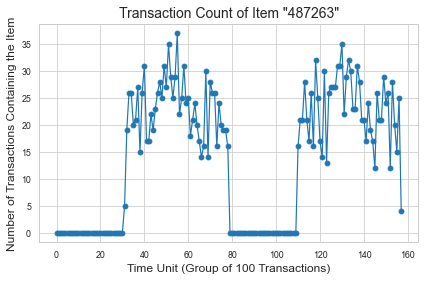

In [184]:
# --- 參數設定 ---
# 您可以更改這兩個參數來觀察不同的商品或不同的時間粒度
ITEM_TO_TRACK = '487263'  # '463806'
CHUNK_SIZE = 100         # 每100筆交易為一個時間點

item_counts_over_time = []
for i in range(0, len(all_txns), CHUNK_SIZE):
    chunk = all_txns[i:i + CHUNK_SIZE]
    # 計算在當前這個 chunk 中，有多少筆交易包含了目標商品
    count = sum(1 for txn in chunk if ITEM_TO_TRACK in txn)
    item_counts_over_time.append(count)

# --- 繪製折線圖 ---
# plt.figure(figsize=(12, 6))
plt.plot(item_counts_over_time, marker='o', linestyle='-')

plt.title(f'Transaction Count of Item "{ITEM_TO_TRACK}"', fontsize=14)
plt.xlabel(f'Time Unit (Group of {CHUNK_SIZE} Transactions)', fontsize=12)
plt.ylabel(f'Number of Transactions Containing the Item', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


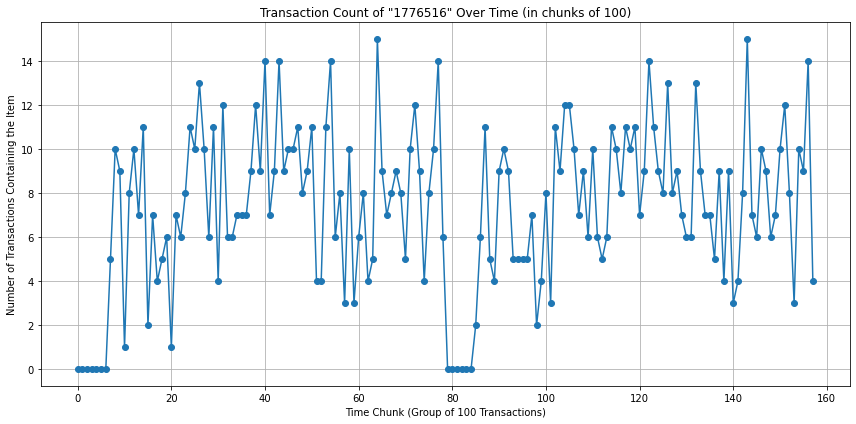

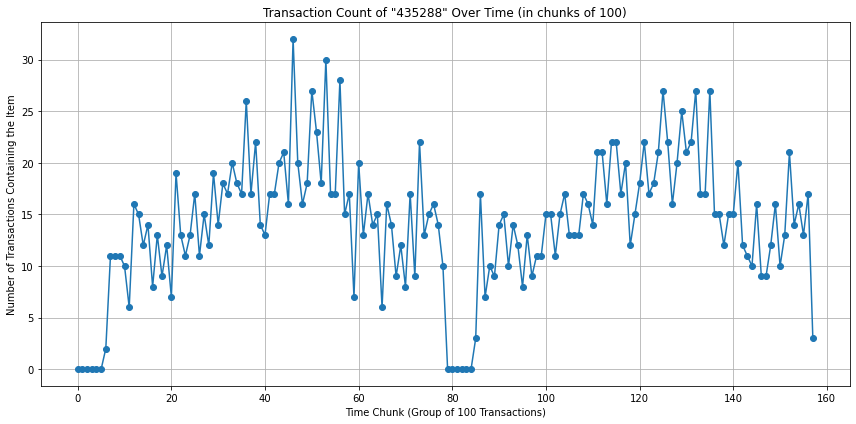

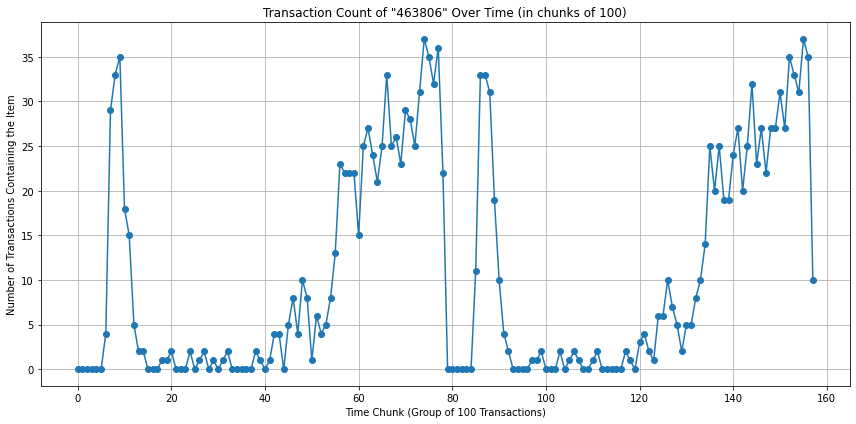

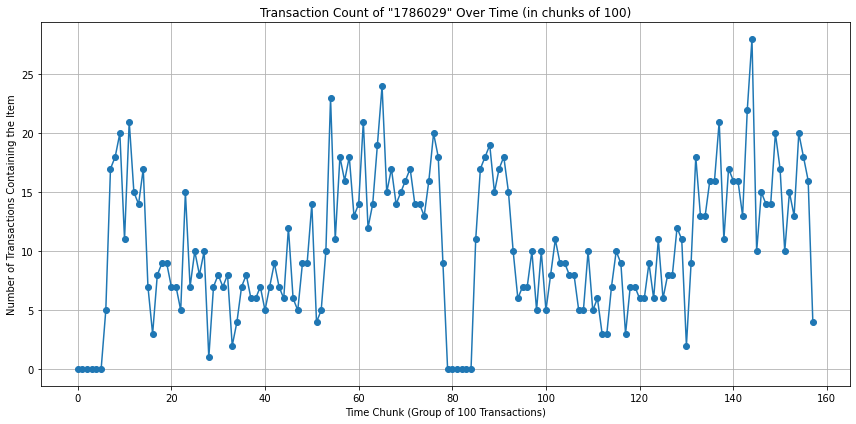

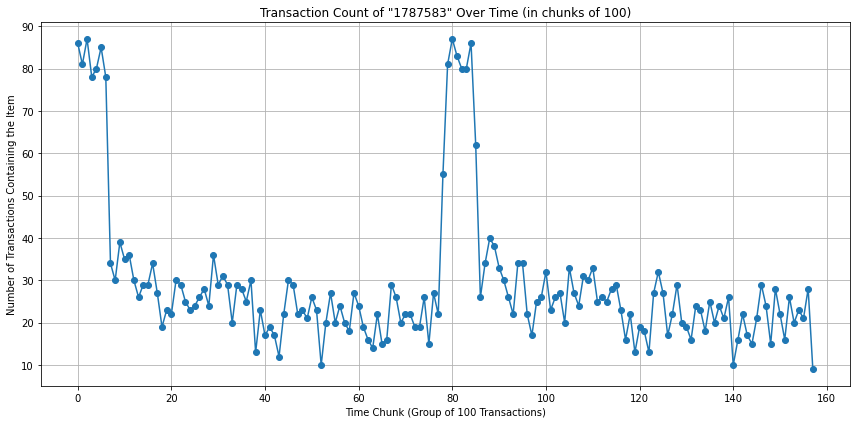

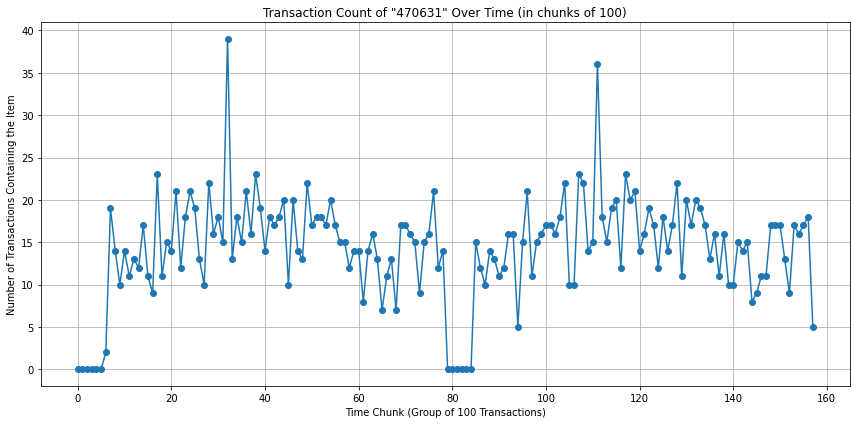

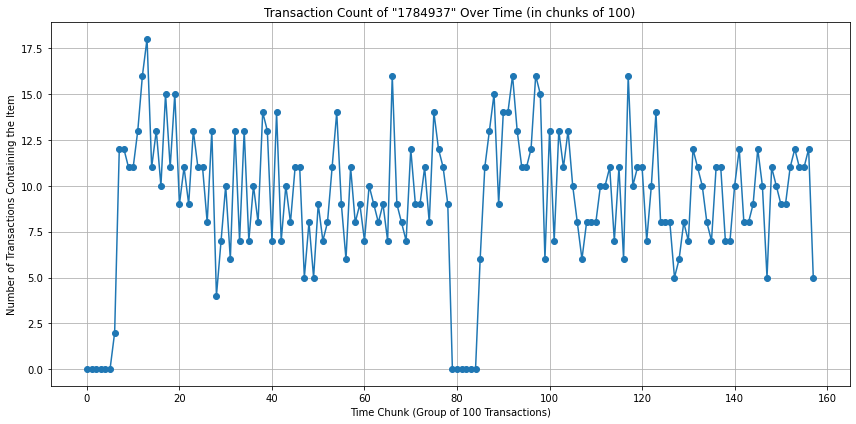

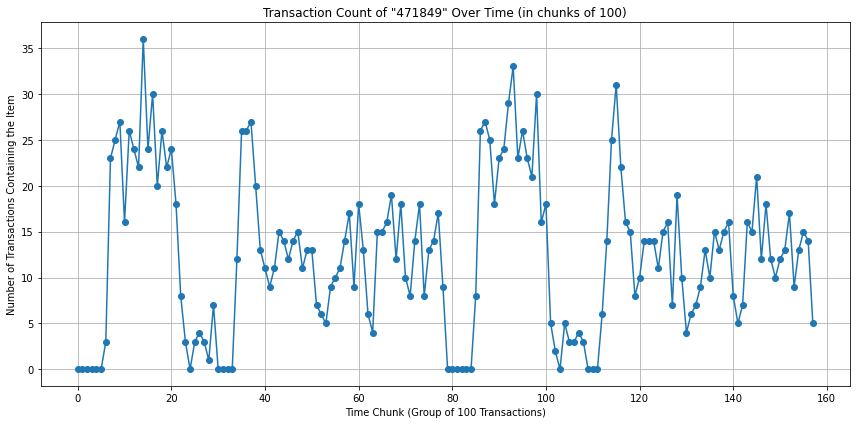

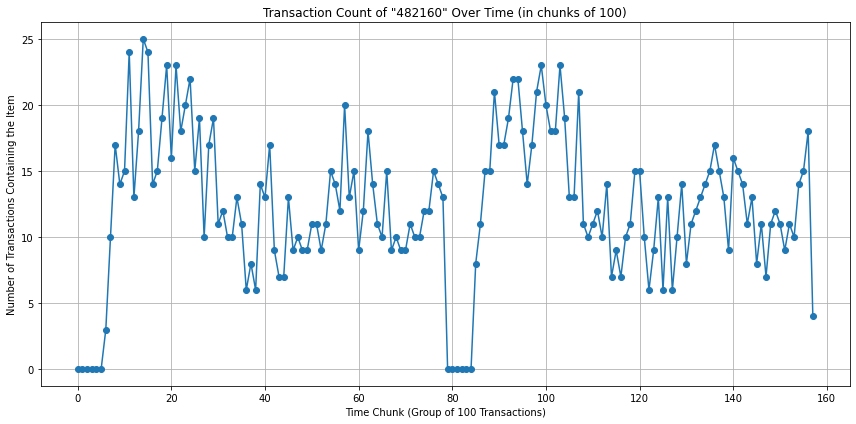

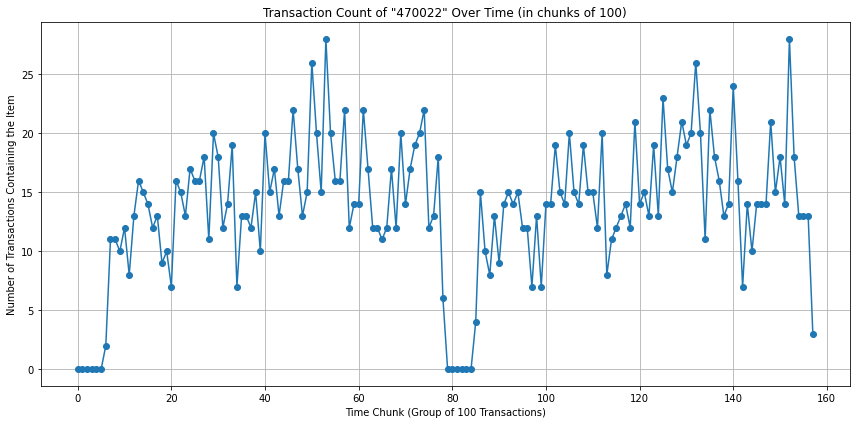

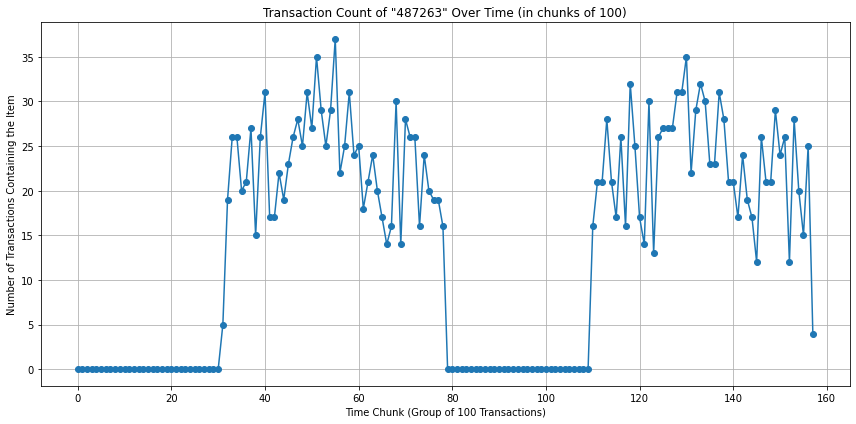

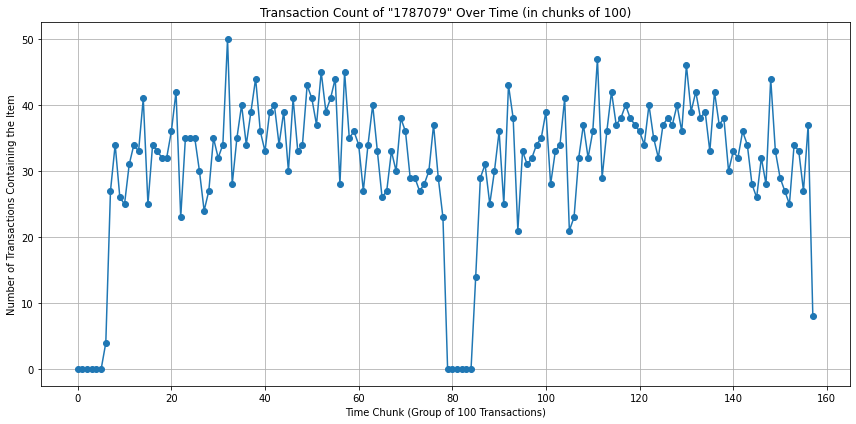

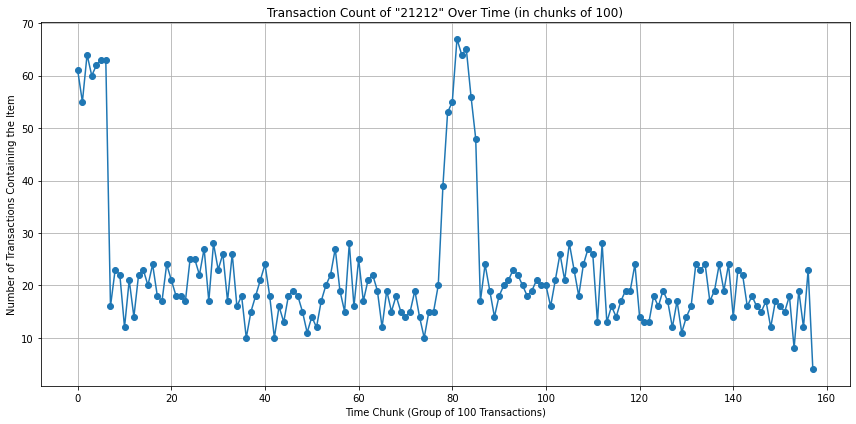

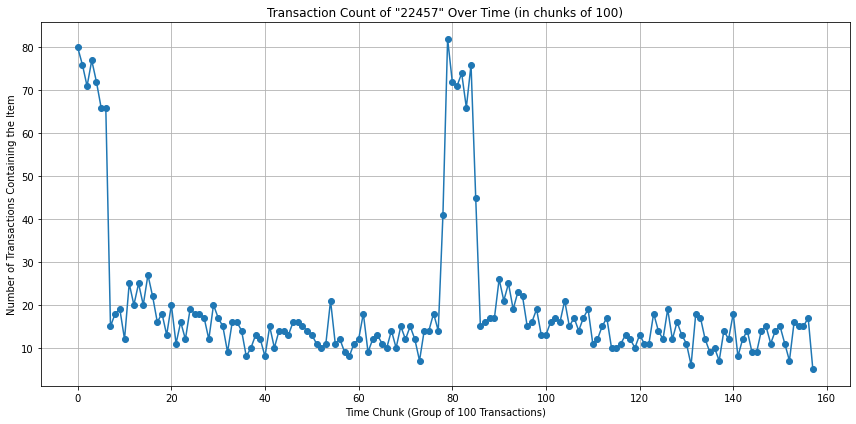

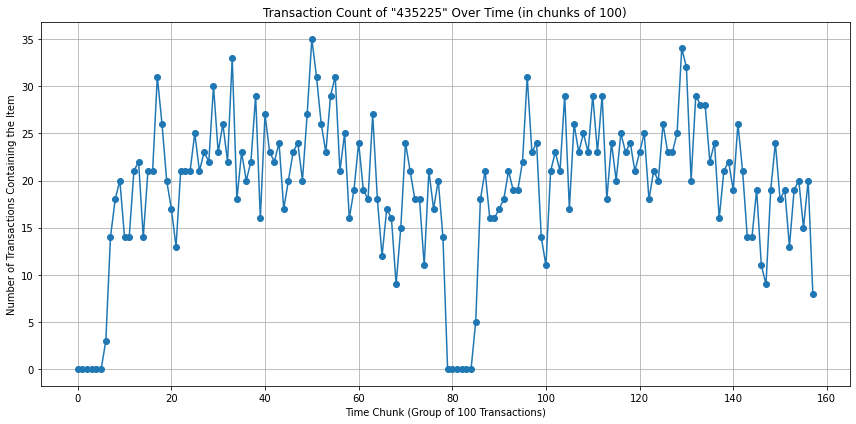

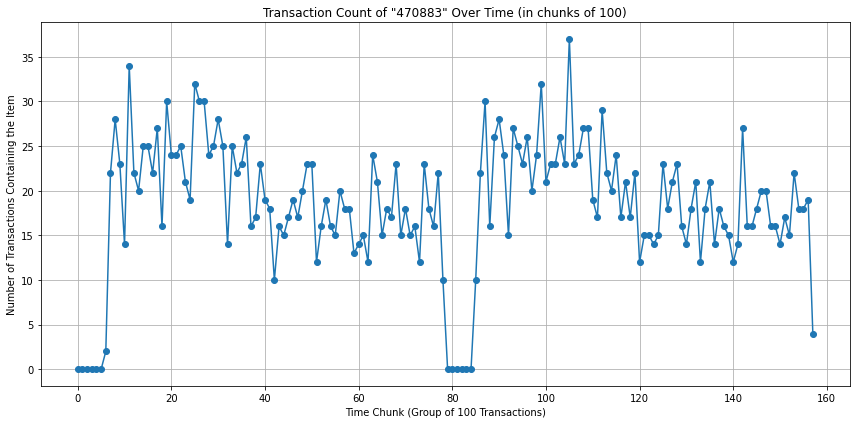

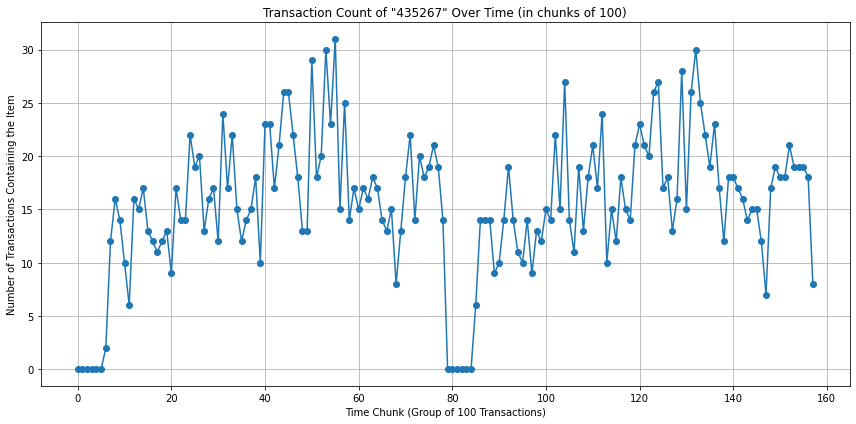

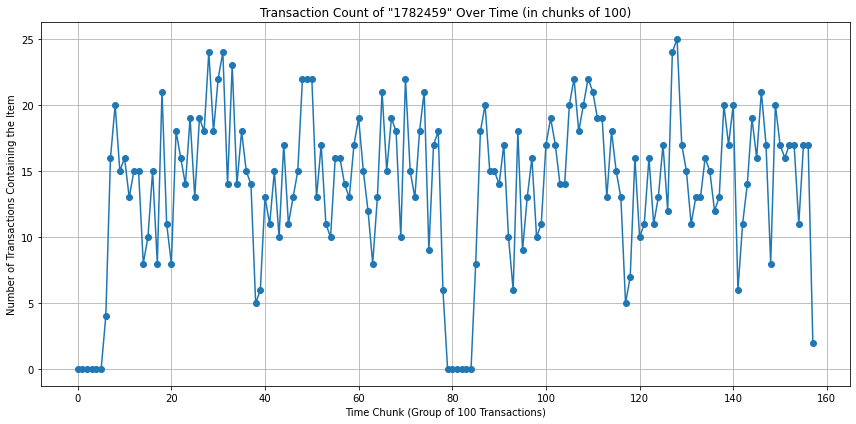

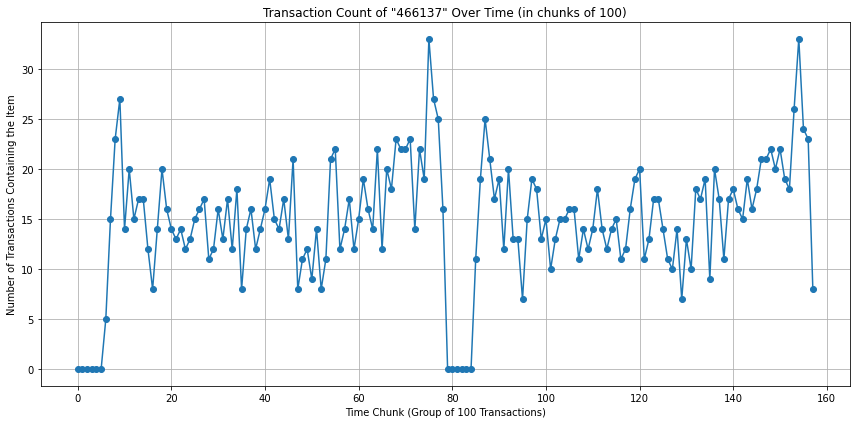

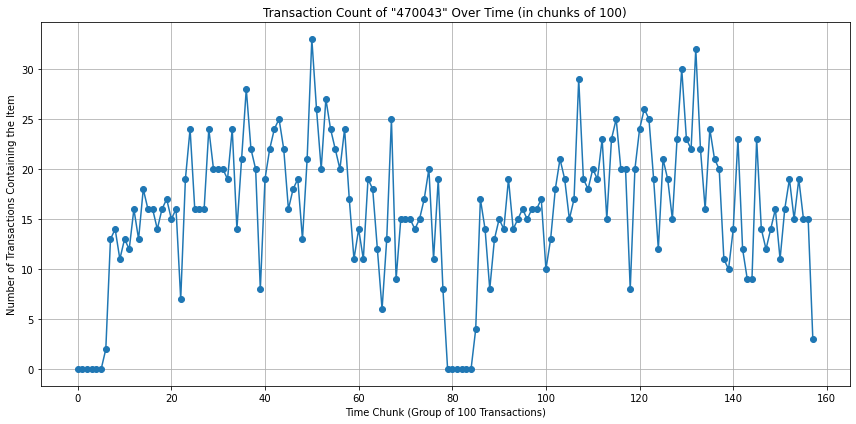

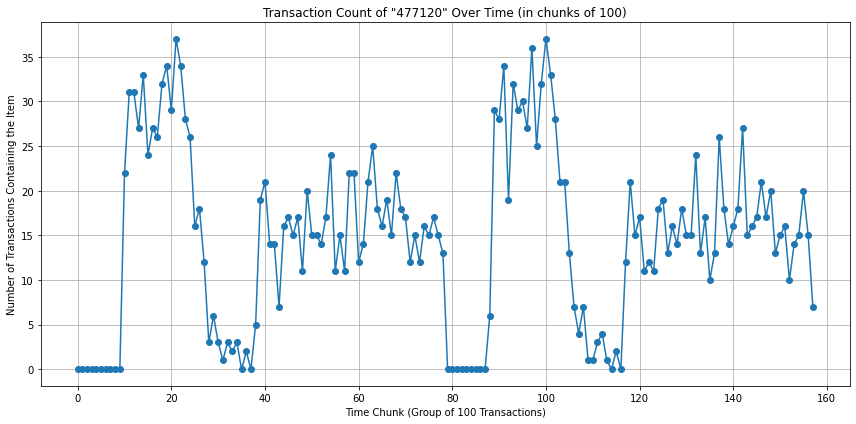

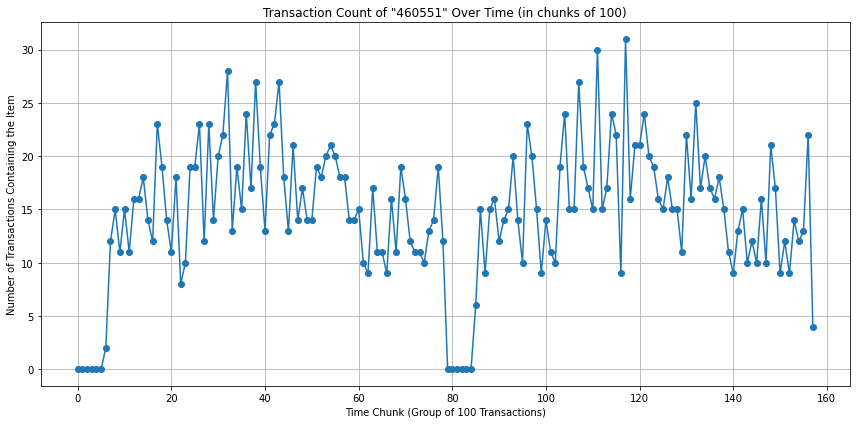

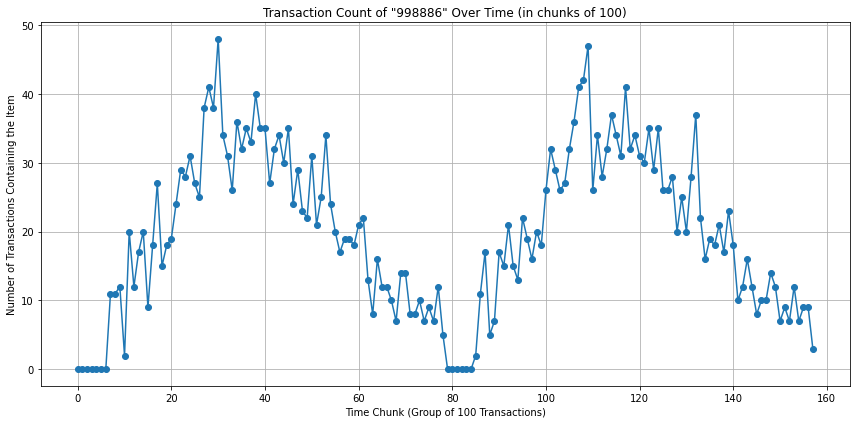

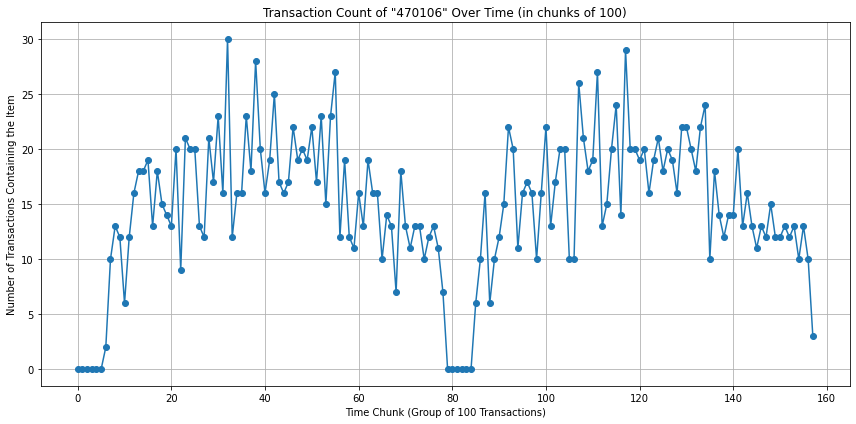

In [332]:

for item in unique_items:
    ITEM_TO_TRACK = item  # 逐一處理每個商品
    # --- 計算每個時間組的商品頻率 ---
    item_counts_over_time = []
    for i in range(0, len(all_txns), CHUNK_SIZE):
        chunk = all_txns[i:i + CHUNK_SIZE]
        # 計算在當前這個 chunk 中，有多少筆交易包含了目標商品
        count = sum(1 for txn in chunk if ITEM_TO_TRACK in txn)
        item_counts_over_time.append(count)

    # --- 繪製折線圖 ---
    plt.figure(figsize=(12, 6))
    plt.plot(item_counts_over_time, marker='o', linestyle='-')

    plt.title(f'Transaction Count of "{ITEM_TO_TRACK}" Over Time (in chunks of {CHUNK_SIZE})')
    plt.xlabel(f'Time Chunk (Group of {CHUNK_SIZE} Transactions)')
    plt.ylabel(f'Number of Transactions Containing the Item')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

##### train

In [211]:
import time
import pickle
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 在新的交錯訓練集上進行特徵提取與模型訓練

# --- 1. 基礎設置與統計 (基於新的訓練集) ---
t0 = time.time()
train_txns_for_model = train_txns_interleaved # 使用我們剛剛創建的交錯訓練集
freq_counter_interleaved = Counter(i for t in train_txns_for_model for i in t)
unique_items_interleaved = sorted(freq_counter_interleaved)
enc_interleaved = LabelEncoder()
enc_interleaved.fit(unique_items_interleaved)
N_interleaved = len(train_txns_for_model)

print(f"training set: {N_interleaved} transactions, {len(unique_items_interleaved)} items")

# --- 2. 特徵抽取 (使用您靜態實驗中的完整邏輯) ---
t1 = time.time()
# 重新建立 FP-tree-like 結構
real_root_interleaved = FPNode()
features_interleaved, labels_interleaved = [], []

for txn in train_txns_for_model:
    seq = sorted(txn, key=lambda x: -freq_counter_interleaved[x])
    codes = enc_interleaved.transform(seq)
    node = real_root_interleaved
    node.count += 1
    prefix = []
    for c in codes:
        # 建立特徵向量 (包含豐富的機率特徵)
        pv = np.zeros(len(unique_items_interleaved), int)
        for p in prefix: pv[p] = 1
        
        cc = np.zeros(len(unique_items_interleaved), int)
        for ch, nd in node.children.items(): cc[ch] = nd.count
        
        pc, pl = node.count, len(prefix)
        
        item = enc_interleaved.inverse_transform([c])[0]
        p_c = freq_counter_interleaved[item] / N_interleaved

        if prefix:
            last_code = prefix[-1]
            last_item = enc_interleaved.inverse_transform([last_code])[0]
            p_p = freq_counter_interleaved[last_item] / N_interleaved
        else:
            p_p = 1.0
        
        edge_ct = node.children.get(c, type(node)()).count
        p_edge = edge_ct / N_interleaved
        p_bound = p_c * p_p * p_edge

        feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
        features_interleaved.append(feat)
        labels_interleaved.append(c)

        # 插入節點
        if c not in node.children:
            nd = type(node)(code=c)
            nd.count = 0
            node.children[c] = nd
        node = node.children[c]
        node.count += 1
        prefix.append(c)

real_root_interleaved.count = N_interleaved
X_interleaved = np.array(features_interleaved)
y_interleaved = np.array(labels_interleaved)
feature_time = time.time() - t1
print(f"{X_interleaved.shape[0]} features, time: {feature_time:.2f} s")

# --- 3. XGBoost 模型訓練 ---
t2 = time.time()
item_models_interleaved = {}
for code in range(len(unique_items_interleaved)):
    yb = (y_interleaved == code).astype(int)
    if yb.sum() < 30: continue  # 避免樣本過少的類別
    mdl = XGBClassifier(
       objective='binary:logistic',
       use_label_encoder=False, eval_metric='logloss',
       n_estimators=100, max_depth=6, learning_rate=0.1
    )
    mdl.fit(X_interleaved, yb)
    item_models_interleaved[code] = mdl
train_time = time.time() - t2
print(f"train {len(item_models_interleaved)} models, time {train_time:.2f} s")

# --- 4. 保存模型與所需物件 ---
artifacts_interleaved = {
    'models': item_models_interleaved,
    'encoder': enc_interleaved,
    'freq_counter': freq_counter_interleaved,
    'real_root': real_root_interleaved,
    'num_total_txns': N_interleaved,
    'unique_items': unique_items_interleaved
}


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


training set: 7900 transactions, 24 items
30462 features, time: 4.92 s
train 24 models, time 8.19 s


##### evaluate model and plot

In [213]:
from sklearn.metrics import top_k_accuracy_score, accuracy_score
import pandas as pd

# --- 1. Prepare Test Data Features and Labels ---
# You must process the test data the same way you processed the training data
# to get the corresponding features (X_te) and labels (y_te).

print("Preparing features and labels for the test set...")
t_eval_start = time.time()

features_te, labels_te = [], []
# Use the same freq_counter from training to maintain consistent sorting
for txn in test_txns_interleaved:
    # Sort test transactions by the frequency learned from the training set
    seq = sorted(txn, key=lambda x: -freq_counter_interleaved.get(x, 0))
    codes = enc_interleaved.transform(seq)
    
    node = real_root_interleaved # Use the tree built from the training data
    prefix = []
    for c in codes:
        # Create the feature vector for this step in the transaction
        pv = np.zeros(len(unique_items_interleaved), int)
        for p in prefix: pv[p] = 1
        
        cc = np.zeros(len(unique_items_interleaved), int)
        if node: # Check if the node exists in the trained tree
            for ch, nd in node.children.items(): cc[ch] = nd.count
        
        pc = node.count if node else 0
        pl = len(prefix)

        item = enc_interleaved.inverse_transform([c])[0]
        p_c = freq_counter_interleaved.get(item, 0) / N_interleaved

        p_p = 1.0
        if prefix:
            last_code = prefix[-1]
            last_item = enc_interleaved.inverse_transform([last_code])[0]
            p_p = freq_counter_interleaved.get(last_item, 0) / N_interleaved

        edge_ct = node.children.get(c, type(node)()).count if node else 0
        p_edge = edge_ct / N_interleaved
        p_bound = p_c * p_p * p_edge

        feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
        features_te.append(feat)
        labels_te.append(c)

        # Traverse the tree
        if node and c in node.children:
            node = node.children[c]
        else:
            # If the path doesn't exist in the training tree, stop for this transaction
            node = None 
        prefix.append(c)

X_te = np.array(features_te)
y_te = np.array(labels_te)

print(f"Test feature preparation complete. Found {len(X_te)} samples.")

# --- 2. Predict Probabilities for the Test Set ---
print("Predicting probabilities for the test set...")
models = artifacts_interleaved['models']
unique_items = artifacts_interleaved['unique_items']

# Initialize a probability matrix for all test samples and all possible items
proba = np.zeros((len(X_te), len(unique_items)))

# For each test sample, predict the probability of each item being next
for i, xi in enumerate(X_te):
    xi_reshaped = xi.reshape(1, -1)
    for code, model in models.items():
        # The model predicts the probability of class 1 (the item being present)
        proba[i, code] = model.predict_proba(xi_reshaped)[0, 1]

# --- 3. Calculate Top-K Accuracy ---
print("Calculating top-k accuracy...")
results = {
    'top1_acc': accuracy_score(y_te, proba.argmax(axis=1)),
    'top2_acc': top_k_accuracy_score(y_te, proba, k=2, labels=range(len(unique_items))),
    'top3_acc': top_k_accuracy_score(y_te, proba, k=3, labels=range(len(unique_items))),
    'top4_acc': top_k_accuracy_score(y_te, proba, k=4, labels=range(len(unique_items))),
    'top5_acc': top_k_accuracy_score(y_te, proba, k=5, labels=range(len(unique_items))),
}
results['eval_time_s'] = time.time() - t_eval_start

# --- 4. Print Results ---
print("\n--- Evaluation Results ---")
print(f"Total evaluation time: {results['eval_time_s']:.2f} seconds")
print(f"Top-1 Accuracy: {results['top1_acc']:.4f}")
print(f"Top-2 Accuracy: {results['top2_acc']:.4f}")
print(f"Top-3 Accuracy: {results['top3_acc']:.4f}")
print(f"Top-4 Accuracy: {results['top4_acc']:.4f}")
print(f"Top-5 Accuracy: {results['top5_acc']:.4f}")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Preparing features and labels for the test set...
Test feature preparation complete. Found 30022 samples.
Predicting probabilities for the test set...
Calculating top-k accuracy...

--- Evaluation Results ---
Total evaluation time: 542.82 seconds
Top-1 Accuracy: 0.6986
Top-2 Accuracy: 0.8290
Top-3 Accuracy: 0.8839
Top-4 Accuracy: 0.9120
Top-5 Accuracy: 0.9363


In [214]:
# time
print(f"feature extraction time: {feature_time:.2f} seconds")
print(f"model training time: {train_time:.2f} seconds")
print(f"evaluation time: {results['eval_time_s']:.2f} seconds")

# dataset size
print(f"Training set size: {len(train_txns_interleaved)} transactions")
print(f"Test set size: {len(test_txns_interleaved)} transactions")

feature extraction time: 4.92 seconds
model training time: 8.19 seconds
evaluation time: 542.82 seconds
Training set size: 7900 transactions
Test set size: 7828 transactions


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


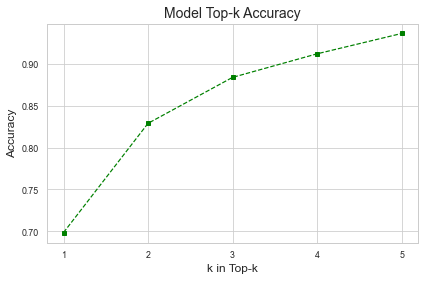

In [206]:
# plot the top-k accuracies
import matplotlib.pyplot as plt
k_values = [1, 2, 3, 4, 5]
top_k_accuracies = [results[f'top{k}_acc'] for k in k_values]
# plt.figure(figsize=(10, 6))
plt.plot(k_values, top_k_accuracies, marker='s', linestyle='--', color='g')
plt.xticks(k_values)

plt.title('Model Top-k Accuracy', fontsize=14)
plt.xlabel('k in Top-k', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.savefig('./figures/model/top_k_accuracy_stream.png')
plt.show()

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


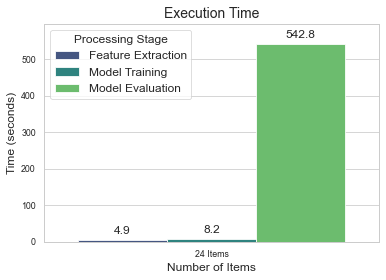

In [217]:
# plot time spent
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# --- Data Preparation ---
# Using the same three experiments with English labels
time_data = {
    'Number of Items': ["24 Items"],
    'Feature Extraction': [feature_time],
    'Model Training': [train_time],
    'Model Evaluation': [results['eval_time_s']]
}


df_time = pd.DataFrame(time_data)

# Melt the dataframe to prepare for grouped bar plot
df_time_melted = df_time.melt(id_vars='Number of Items', var_name='Processing Stage', value_name='Time (seconds)')

# --- Plotting ---
# plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_time_melted, x='Number of Items', y='Time (seconds)', hue='Processing Stage', palette='viridis')

# --- Formatting ---
plt.title('Execution Time', fontsize=14)
plt.xlabel('Number of Items', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.legend(title='Processing Stage', fontsize=12, title_fontsize='12')

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12)

# Show the plot
plt.ylim(0, df_time_melted['Time (seconds)'].max() * 1.1)  # Set y-limit for better visibility
plt.savefig('./figures/model/execution_time_stream.png', bbox_inches='tight')
plt.show()

In [28]:
# num of models
print(f"Total models trained: {len(artifacts_interleaved['models'])}")

Total models trained: 24


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [29]:
artifact_filename = f'fp_model_artifacts_{num_items}_interleaved.pkl'
with open(artifact_filename, 'wb') as f:
    pickle.dump(artifacts_interleaved, f)
    
print(f"save '{artifact_filename}'。")

save 'fp_model_artifacts_24_interleaved.pkl'。


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### 靜態test

##### ML

In [155]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder

# print("\n--- 步驟 3：在交錯測試集上進行驗證與評估 ---")

# --- 參數設定 ---
MIN_SUPPORT = 0.11  # 我們可以從0.01開始，看看召回率表現
PROBA_THRESHOLD = 0.01

artifact_filename = f'fp_model_artifacts_{num_items}_interleaved.pkl'


# --- 載入新訓練的模型產物 ---
with open(artifact_filename, 'rb') as f:
    loaded_artifacts_interleaved = pickle.load(f)

# --- 執行混合式ML探勘方法 ---
print(f"[min_sup={MIN_SUPPORT})]")

ml_patterns_interleaved, gen_time, val_time, ml_cand_count = run_hybrid_generation(
    artifacts=loaded_artifacts_interleaved,
    min_support_threshold=MIN_SUPPORT,
    dataset_prct=1.0, # 這裡設為1.0，因為我們直接傳入 txns_train
    top_k_expansion=None, 
    proba_threshold=PROBA_THRESHOLD,
    dataset=test_txns_interleaved
    # txns_train=test_txns_interleaved  # << 關鍵：這裡傳入的是測試集
)


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[min_sup=0.11)]
this version does NOT keep same patterns in different orders
--- Level 1: Validating single items --- (minimum support threshold = 0.11)
Found 20 frequent patterns with support >= 0.11 in 7828 transactions.
Validation ratio: 83.33%: 20/24
not selected 4 patterns support: avg=0.0950, max=0.1076, min=0.0726, median=0.1000
selected 20 patterns support: avg=0.1728, max=0.3067, min=0.1249, median=0.1488

--- Level 2: Generating candidates from 20 frequent patterns ---
Generated 460 feature vectors for Level 2.
top-k_expansion: None, proba_threshold: 0.01
Generated 286 candidates for Level 2 with probability > 0.01.
After Apriori pruning, 211 candidates remain.
Generated 286 ordered candidates, which resulted in 188 unique sets for validation.
Found 0 frequent patterns with support >= 0.11 in 7828 transactions.
Validation ratio: 0.00%: 0/188
not selected 188 patterns support: avg=0.0360, max=0.1088, min=0.0097, median=0.0316
Validation completed for Level 2 in 0.89 seconds.
N

##### compare

In [156]:
# --- 執行FP-growth作為基準 (Ground Truth) ---
fp_start_time = time.time()
te = TransactionEncoder()
te_ary = te.fit(test_txns_interleaved).transform(test_txns_interleaved)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)
fp_results = fpgrowth(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
ground_truth_patterns = fp_results['itemsets']
fp_time = time.time() - fp_start_time
print(f"FP-Growth: found {len(ground_truth_patterns)} FP in {fp_time:.2f}s")


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


FP-Growth: found 21 FP in 0.31s


In [157]:
# 使用 run_my_apriori 來執行 Apriori 並顯示時間與候選集數量
my_aprior_frequent_itemsets, _, apriori_time, apriori_candidate_count = run_my_apriori(
    dataset=test_txns_interleaved, min_support=MIN_SUPPORT, dataset_prct=1.0
)

print("\n--- Apriori Time and Candidate Count ---")
print(f"Apriori validation time: {apriori_time:.2f} seconds")
print(f"Apriori candidate count: {apriori_candidate_count}")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Running Apriori with min_support = 0.11...

Found 21 frequent itemsets in total.

Frequent itemsets by length:
Length 1: 20 itemsets
Length 2: 1 itemsets
Pure Python Apriori finished in 0.52 seconds.
Pure Python Apriori generated a total of 214 candidates to validate.

--- Apriori Time and Candidate Count ---
Apriori validation time: 0.52 seconds
Apriori candidate count: 214


In [158]:
tp, tn, fp, fn = calculate_tp_tn_fp_fn_with_encoder(
    ml_patterns_codes=ml_patterns_interleaved.keys(), 
    fp_patterns_names=ground_truth_patterns.tolist(),
    encoder=loaded_artifacts_interleaved['encoder']
)

print_tp_tn_fp_fn(tp, tn, fp, fn)
p, r, f1 = calculate_print_precision_recall_f1(tp, fp, fn)

# time compare
print(f"\n--- Time Comparison (minsup = {MIN_SUPPORT}, {num_items} itmes) ---")
print(f"ML: {(gen_time+val_time):.2f}s, gen {gen_time:.2f}s (candidates: {ml_cand_count}), val {val_time:.2f}s.")
print(f"FP-Growth: {fp_time:.2f}s")
print(f"Apriori: {apriori_time:.2f}s (candidates: {apriori_candidate_count})")

True Positives (TP): 20
False Positives (FP): 0
False Negatives (FN): 1
Precision: 1.0000
Recall: 0.9524
F1 Score: 0.9756

--- Time Comparison (minsup = 0.11, 24 itmes) ---
ML: 1.23s, gen 0.22s (candidates: 188), val 1.01s.
FP-Growth: 0.31s
Apriori: 0.52s (candidates: 214)


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [159]:
print(len(test_txns_interleaved))

7828


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 滑動窗口 test data stream 

##### function

In [30]:
### 修正特徵生成邏輯
### 進行滑動窗口資料流模擬 

import pandas as pd
import numpy as np
import time
import pickle
from collections import Counter
from itertools import combinations
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt


# --- 3. 為「推論」階段定義的特徵提取函數 ---
# 這個函數使用訓練時的 artifacts 來生成特徵
# def extract_features_for_inference(prefix_codes, artifacts):
#     num_unique_items = len(artifacts['unique_items'])
    
#     # << 關鍵：使用訓練時的 FP-tree (real_root)
#     node = artifacts['real_root'] 
#     for code in prefix_codes:
#         if code in node.children:
#             node = node.children[code]
#         else:
#             return None 

#     # 準備特徵
#     pv = np.zeros(num_unique_items, int)
#     for p in prefix_codes: pv[p] = 1

#     cc = np.zeros(num_unique_items, int)
#     for ch, nd in node.children.items(): cc[ch] = nd.count

#     pc, pl = node.count, len(prefix_codes)
    
#     p_p = 1.0
#     if prefix_codes:
#         last_item = artifacts['encoder'].inverse_transform([prefix_codes[-1]])[0]
#         # << 關鍵：使用訓練時的頻率計數器
#         p_p = artifacts['freq_counter'].get(last_item, 0) / artifacts['num_total_txns']

#     base_features = (pv, cc, pc, pl, p_p, node)
#     return base_features

def run_sliding_window(artifact_filename, min_support=0.09, start_offset=0, window_size=1000, step_size=10, n_windows=20, prob=0.01, top_k=None):
    # --- 2. 載入模型與數據 ---
    # print(f"載入模型產物: '{artifact_filename}'")
    with open(artifact_filename, 'rb') as f:
        artifacts = pickle.load(f)

    # 使用方案一中切分好的測試集數據
    # train_txns_interleaved 和 test_txns_interleaved 應該在您的notebook環境中已經存在
    txns_for_streaming = test_txns_interleaved
    txns_sets_for_streaming = [set(t) for t in txns_for_streaming]


    # --- 4. 模擬滑動窗口 ---
    streaming_results = []

    for i in range(n_windows):
        window_start = start_offset + i * step_size
        window_end = window_start + window_size
        if window_end > len(txns_for_streaming):
            # 如果只想處理一個完整的窗口，就中斷
            if i == 0:
                window_end = len(txns_for_streaming)
            else:
                break

        window_txns = txns_for_streaming[window_start:window_end]
        window_txns_sets = txns_sets_for_streaming[window_start:window_end]
        
        print(f"windows {i+1}/{n_windows} ({window_start}-{window_end})...")

        # --- A. ML 方法 ---
        ml_start_time = time.time()

        ml_frequent_patterns_tuples, gen_time, val_time, ml_cand_count = run_hybrid_generation(
            artifacts=artifacts,
            min_support_threshold=min_support,
            dataset_prct=1.0, # 這裡設為1.0，因為我們直接傳入 txns_train
            top_k_expansion= top_k, 
            proba_threshold= prob,
            dataset=window_txns
        )

        ml_time = time.time() - ml_start_time
        
        # 將字典的鍵（code tuples）轉換為set
        ml_frequent_patterns = set(ml_frequent_patterns_tuples.keys())

        # --- B. FP-Growth 基準 ---
        fpg_start_time = time.time()
        te = TransactionEncoder()
        te_ary = te.fit(window_txns).transform(window_txns)
        df_onehot = pd.DataFrame(te_ary, columns=te.columns_)
        fp_results = fpgrowth(df_onehot, min_support=min_support, use_colnames=True)
        ground_truth_names = {tuple(sorted(p)) for p in fp_results['itemsets']}
        fpg_time = time.time() - fpg_start_time

        # --- C. Apriori 基準 ---
        # 使用 run_my_apriori 來執行 Apriori 並顯示時間與候選集數量
        my_aprior_frequent_itemsets, _, apriori_time, apriori_candidate_count = run_my_apriori(
            dataset=window_txns, min_support=min_support, dataset_prct=1.0
        )

        print(f"Apriori validation time: {apriori_time:.2f} seconds")
        print(f"Apriori candidate count: {apriori_candidate_count}")
        print(f"Aprirori found {len(my_aprior_frequent_itemsets)} frequent itemsets.")

        # --- 評估 ---
        # 將 ML 的 code tuple 結果轉為 name tuple 以便比較
        encoder = artifacts['encoder']
        ml_frequent_patterns_names = set()
        for code_tuple in ml_frequent_patterns:
            names = encoder.inverse_transform(list(code_tuple))
            ml_frequent_patterns_names.add(tuple(sorted(names)))

        TP = len(ml_frequent_patterns_names.intersection(ground_truth_names))
        FP = len(ml_frequent_patterns_names.difference(ground_truth_names))
        FN = len(ground_truth_names.difference(ml_frequent_patterns_names))
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        streaming_results.append({
            "window_start": window_start,
            "ML_Time": ml_time,
            "FPG_Time": fpg_time,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ML_Count": len(ml_frequent_patterns),
            "GT_Count": len(ground_truth_names),
            "ML_Candidate": ml_cand_count,
            "Apriori_Candi": apriori_candidate_count,
            "Gen_Time": gen_time,
            "Val_Time": val_time,
            "Apriori_Time": apriori_time,
        })

    # --- 5. 輸出結果 ---
    results_df = pd.DataFrame(streaming_results)
    # print("\n--- 修正後的資料流模擬結果 ---")
    print(results_df.to_string())
    return results_df, streaming_results



c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


##### 跑多個支持度

In [ ]:

# --- 1. 參數設定 ---
num_items = 24
dataset_path = f'./data/dataset_{num_items}_items_2.csv'
# 載入在交錯數據上訓練好的模型
artifact_filename = f'fp_model_artifacts_{num_items}_interleaved.pkl' 

# 滑動窗口參數
WINDOW_SIZE = 5000 #3900  # 測試集的大小
STEP_SIZE = 10      
N_WINDOWS_TO_RUN = 20 # 跑幾個窗口

start_offset = 0 #300  # 從測試集的開頭開始

# 探勘參數
MIN_SUPPORT = 0.03 # 不同支持度
PROBA_THRESHOLD = 0.01
TOP_K = None

results_df = run_sliding_window(
    artifact_filename=artifact_filename,
    min_support=MIN_SUPPORT,
    start_offset=start_offset,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    n_windows=N_WINDOWS_TO_RUN,
    prob=PROBA_THRESHOLD,
    top_k=TOP_K
)


def run_different_support(sup=0.09):
    """
    執行滑動窗口資料流模擬，並返回結果 DataFrame。
    """
    print(f"Running sliding window with min_support = {sup}...")
    
    # 使用指定的支持度參數執行滑動窗口
    results_df, streaming_results = run_sliding_window(
        artifact_filename=artifact_filename,
        min_support=sup,
        start_offset=start_offset,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        n_windows=N_WINDOWS_TO_RUN,
        prob=PROBA_THRESHOLD,
        top_k=TOP_K
    )

    print(f"minsup={MIN_SUPPORT}, windows size = {WINDOW_SIZE}, step size = {STEP_SIZE}, total windows = {N_WINDOWS_TO_RUN} (PROBA_THRESHOLD={PROBA_THRESHOLD}, TOP_K={TOP_K})")

    # append avg to results_df
    # 一次性計算所有數值欄位的平均值
    avg_row = results_df.mean(numeric_only=True).to_frame().T

    # 將 avg_row 中所有的數值四捨五入到小數點後兩位
    avg_row = avg_row.round(6)

    # 設置非數值欄位的標籤
    avg_row['window_start'] = 'Average'

    # 將處理好的平均值列加回到原本的 DataFrame
    results_df = pd.concat([results_df, avg_row], ignore_index=True)
    print(results_df.to_string(index=False))

    # 儲存結果到 CSV 檔案
    # save results to a CSV file
    results_df.to_csv(f'./data/stream_result/stream_results_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}.csv', index=False)
    print(f"Results saved to './data/stream_result/stream_results_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}.csv'")


    
    return results_df

# 執行不同支持度的滑動窗口模擬
support_values = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]
all_results = {}
for support in support_values:
    results_df = run_different_support(sup=support)
    all_results[support] = results_df
    print(f"\nResults for min_support = {support}:\n{results_df}")
# 儲存所有結果到檔案
with open('sliding_window_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
# 儲存結果到 CSV 檔案
for support, df in all_results.items():
    df.to_csv(f'sliding_window_results_{support}.csv', index=False)
    print(f"Results for min_support = {support} saved to sliding_window_results_{support}.csv")

# --- 2. 繪製結果圖表 ---
import matplotlib.pyplot as plt





##### 手動跑

In [222]:

# --- 1. 參數設定 ---
num_items = 24
dataset_path = f'./data/dataset_{num_items}_items_2.csv'
# 載入在交錯數據上訓練好的模型
artifact_filename = f'fp_model_artifacts_{num_items}_interleaved.pkl' 

# 滑動窗口參數
WINDOW_SIZE = 500 #3900  # 測試集的大小
STEP_SIZE = 100
N_WINDOWS_TO_RUN = 2#0 # 跑幾個窗口

start_offset = 2000 #500 #1000  # 0 從測試集的開頭開始

# 探勘參數
MIN_SUPPORT = 0.01 # 不同支持度
PROBA_THRESHOLD = 0.01 #0.0001 #1e-5#0.01
TOP_K = None

TOP_K = None

results_df, streaming_results = run_sliding_window(
    artifact_filename=artifact_filename,
    min_support=MIN_SUPPORT,
    start_offset=start_offset,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    n_windows=N_WINDOWS_TO_RUN,
    prob=PROBA_THRESHOLD,
    top_k=TOP_K
)

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


windows 1/2 (2000-2500)...
this version does NOT keep same patterns in different orders
--- Level 1: Validating single items --- (minimum support threshold = 0.01)
Found 24 frequent patterns with support >= 0.01 in 500 transactions.
Validation ratio: 100.00%: 24/24
selected 24 patterns support: avg=0.1696, max=0.3580, min=0.0440, median=0.1630

--- Level 2: Generating candidates from 24 frequent patterns ---
Generated 529 feature vectors for Level 2.
top-k_expansion: None, proba_threshold: 0.01
Generated 327 candidates for Level 2 with probability > 0.01.
After Apriori pruning, 327 candidates remain.
Generated 327 ordered candidates, which resulted in 269 unique sets for validation.
Found 240 frequent patterns with support >= 0.01 in 500 transactions.
Validation ratio: 89.22%: 240/269
not selected 29 patterns support: avg=0.0054, max=0.0080, min=0.0020, median=0.0060
selected 240 patterns support: avg=0.0383, max=0.1480, min=0.0100, median=0.0300
Validation completed for Level 2 in 0.0

##### 存數據

In [150]:
print(f"minsup={MIN_SUPPORT}, windows size = {WINDOW_SIZE}, step size = {STEP_SIZE}, total windows = {N_WINDOWS_TO_RUN} (PROBA_THRESHOLD={PROBA_THRESHOLD}, TOP_K={TOP_K})")

# append avg to results_df
# 一次性計算所有數值欄位的平均值
avg_row = results_df.mean(numeric_only=True).to_frame().T

# 將 avg_row 中所有的數值四捨五入到小數點後兩位
avg_row = avg_row.round(6)

# 設置非數值欄位的標籤
avg_row['window_start'] = 'Average'

# 將處理好的平均值列加回到原本的 DataFrame
results_df = pd.concat([results_df, avg_row], ignore_index=True)


print(results_df.to_string(index=False))



minsup=0.11, windows size = 3000, step size = 100, total windows = 20 (PROBA_THRESHOLD=0.01, TOP_K=None)
window_start  ML_Time  FPG_Time  Precision   Recall       F1  ML_Count  GT_Count  ML_Candidate  Apriori_Candi  Gen_Time  Val_Time  Apriori_Time
           0 1.842675  0.305350        1.0 0.954545 0.976744     21.00     22.00         188.0          214.0  0.472075  1.173015      0.169442
         100 1.136135  0.180054        1.0 0.954545 0.976744     21.00     22.00         188.0          214.0  0.312615  0.686622      0.174480
         200 0.854190  0.137526        1.0 0.956522 0.977778     22.00     23.00         188.0          214.0  0.173799  0.564118      0.107001
         300 0.747025  0.153203        1.0 0.956522 0.977778     22.00     23.00         188.0          214.0  0.236815  0.426014      0.098270
         400 0.627257  0.142019        1.0 0.956522 0.977778     22.00     23.00         188.0          214.0  0.141550  0.420106      0.115451
         500 0.639056  0.146816

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [151]:
# save results to a CSV file

if start_offset > 0:
    note = f"_offset{start_offset}.csv"
else:
    note = ""
results_df.to_csv(f'./data/stream_result/stream_results_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}{note}.csv', index=False)

print(f"Results saved to './data/stream_result/stream_results_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}{note}.csv'")

Results saved to './data/stream_result/stream_results_24items_sup0.11_w3000.csv'


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [152]:
print(results_df[['Precision', 'Recall', 'F1', 'ML_Time', 'FPG_Time']].mean())
# print(results_df[['Precision', 'Recall', 'F1', 'ML_Time', 'FPG_Time', 'Apriori_Time']].mean())
print(f"{len(txns)}, minsup={MIN_SUPPORT}, windows size = {WINDOW_SIZE}, step size = {STEP_SIZE}, total windows = {N_WINDOWS_TO_RUN} (PROBA_THRESHOLD={PROBA_THRESHOLD}, TOP_K={TOP_K})")


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Precision    1.000000
Recall       0.956475
F1           0.977752
ML_Time      1.386683
FPG_Time     0.227611
dtype: float64
15728, minsup=0.11, windows size = 3000, step size = 100, total windows = 20 (PROBA_THRESHOLD=0.01, TOP_K=None)


##### plot

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


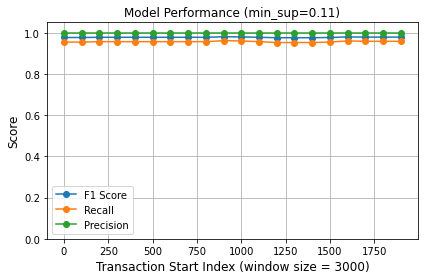

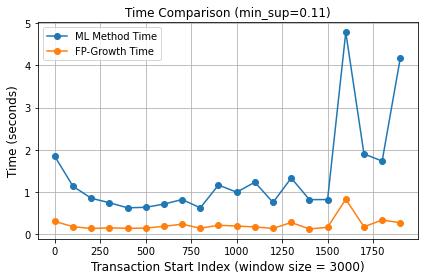

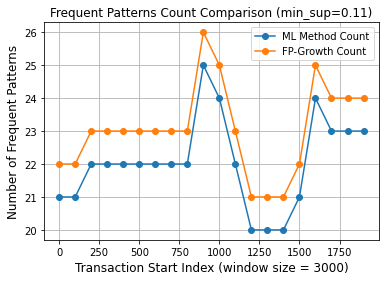

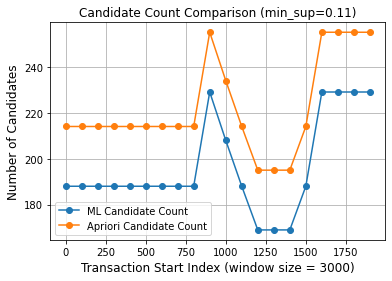

minsup=0.11, windows size = 3000, step size = 100, total windows = 20 (PROBA_THRESHOLD=0.01, TOP_K=None)
Precision    1.000000
Recall       0.956475
F1           0.977752
ML_Time      1.386683
FPG_Time     0.227611
dtype: float64


In [153]:
# --- 結果可視化 ---
# note = f"_offset{start_offset}"
def plot_results(streaming_results):
    results_df = pd.DataFrame(streaming_results)

    # plt.figure(figsize=(10,6))

    # 繪製 F1, Precision, Recall
    plt.plot(results_df["window_start"].values, results_df["F1"].values, marker='o', linestyle='-', label='F1 Score')
    plt.plot(results_df["window_start"].values, results_df["Recall"].values, marker='o', linestyle='-', label='Recall')
    plt.plot(results_df["window_start"].values, results_df["Precision"].values, marker='o', linestyle='-', label='Precision')
    plt.title(f'Model Performance (min_sup={MIN_SUPPORT})') # 模型性能隨時間變化趨勢
    plt.xlabel('Transaction Start Index (window size = {})'.format(WINDOW_SIZE), fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig(f'./figures/data_stream/score_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}{note}.png')
    plt.show()

    # 繪製時間
    # plt.figure(figsize=(10,6))

    plt.plot(results_df["window_start"].values, results_df["ML_Time"].values, marker='o', linestyle='-', label='ML Method Time')
    plt.plot(results_df["window_start"].values, results_df["FPG_Time"].values, marker='o', linestyle='-', label='FP-Growth Time')
    plt.title(f'Time Comparison (min_sup={MIN_SUPPORT})')
    plt.xlabel('Transaction Start Index (window size = {})'.format(WINDOW_SIZE), fontsize=12)
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'./figures/data_stream/time_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}{note}.png')
    plt.show()

    # 頻繁樣式數量
    # plt.figure(figsize=(10,6))
    plt.plot(results_df["window_start"].values, results_df["ML_Count"].values, marker='o', linestyle='-', label='ML Method Count')
    plt.plot(results_df["window_start"].values, results_df["GT_Count"].values, marker='o', linestyle='-', label='FP-Growth Count')
    plt.title(f'Frequent Patterns Count Comparison (min_sup={MIN_SUPPORT})')
    plt.xlabel('Transaction Start Index (window size = {})'.format(WINDOW_SIZE), fontsize=12)
    plt.ylabel('Number of Frequent Patterns', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.savefig(f'./figures/data_stream/count_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}{note}.png')
    plt.show()

    # 候選集數量
    # plt.figure(figsize=(10,6))
    plt.plot(results_df["window_start"].values, results_df["ML_Candidate"].values, marker='o', linestyle='-', label='ML Candidate Count')
    plt.plot(results_df["window_start"].values, results_df["Apriori_Candi"].values, marker='o', linestyle='-', label='Apriori Candidate Count')
    plt.title(f'Candidate Count Comparison (min_sup={MIN_SUPPORT})')
    plt.xlabel('Transaction Start Index (window size = {})'.format(WINDOW_SIZE), fontsize=12)
    plt.ylabel('Number of Candidates', fontsize=12)
    plt.legend()
    plt.grid(True)  
    plt.savefig(f'./figures/data_stream/candidate_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}{note}.png')
    plt.show()

    print(f"minsup={MIN_SUPPORT}, windows size = {WINDOW_SIZE}, step size = {STEP_SIZE}, total windows = {N_WINDOWS_TO_RUN} (PROBA_THRESHOLD={PROBA_THRESHOLD}, TOP_K={TOP_K})")


plot_results(streaming_results)

# 顯示平均結果
# print("--- 平均性能指標 ---")
print(results_df[['Precision', 'Recall', 'F1', 'ML_Time', 'FPG_Time']].mean())

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


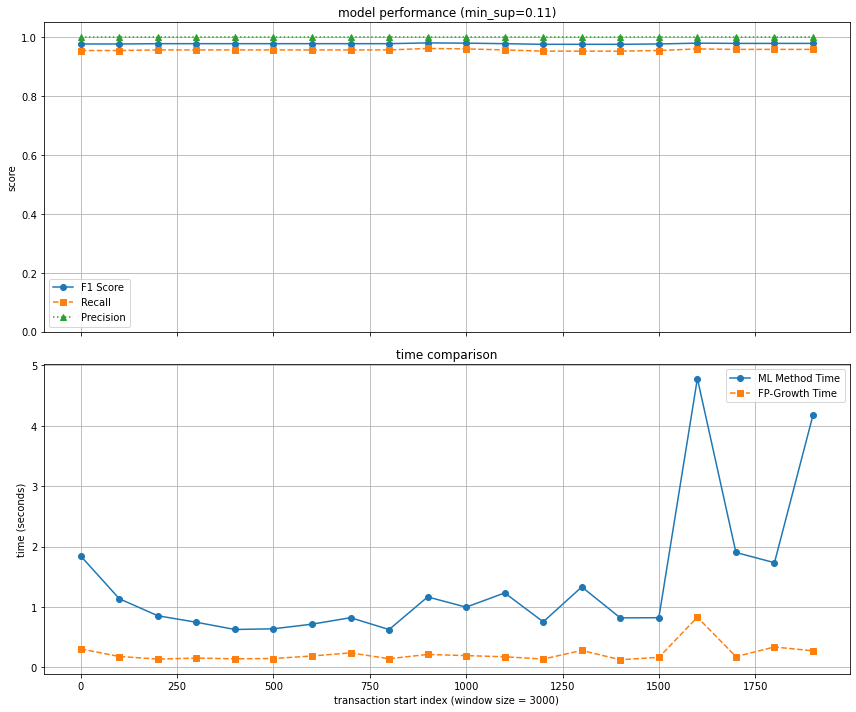

minsup=0.11, windows size = 3000, step size = 100, total windows = 20 (PROBA_THRESHOLD=0.01, TOP_K=None)
Precision    1.000000
Recall       0.956475
F1           0.977752
ML_Time      1.386683
FPG_Time     0.227611
dtype: float64


In [154]:
# --- 1張圖 ---
results_df = pd.DataFrame(streaming_results)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 繪製 F1, Precision, Recall
axes[0].plot(results_df["window_start"].values, results_df["F1"].values, marker='o', linestyle='-', label='F1 Score')
axes[0].plot(results_df["window_start"].values, results_df["Recall"].values, marker='s', linestyle='--', label='Recall')
axes[0].plot(results_df["window_start"].values, results_df["Precision"].values, marker='^', linestyle=':', label='Precision')
axes[0].set_title(f'model performance (min_sup={MIN_SUPPORT})') # 模型性能隨時間變化趨勢
axes[0].set_ylabel('score')
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim(0, 1.05)

# 繪製時間
axes[1].plot(results_df["window_start"].values, results_df["ML_Time"].values, marker='o', linestyle='-', label='ML Method Time')
axes[1].plot(results_df["window_start"].values, results_df["FPG_Time"].values, marker='s', linestyle='--', label='FP-Growth Time')
axes[1].set_title('time comparison')
axes[1].set_xlabel('transaction start index (window size = {})'.format(WINDOW_SIZE))
axes[1].set_ylabel('time (seconds)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'./figures/data_stream/combined_{num_items}items_sup{MIN_SUPPORT}_w{WINDOW_SIZE}.png')
plt.show()
print(f"minsup={MIN_SUPPORT}, windows size = {WINDOW_SIZE}, step size = {STEP_SIZE}, total windows = {N_WINDOWS_TO_RUN} (PROBA_THRESHOLD={PROBA_THRESHOLD}, TOP_K={TOP_K})")

# 顯示平均結果
print(results_df[['Precision', 'Recall', 'F1', 'ML_Time', 'FPG_Time']].mean())

#### run all windows size

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Running sliding window with windows_size = 1000...
windows 1/20 (0-1000)...
this version does NOT keep same patterns in different orders
--- Level 1: Validating single items --- (minimum support threshold = 0.10)
Found 14 frequent patterns with support >= 0.10 in 1000 transactions.
Validation ratio: 58.33%: 14/24
not selected 10 patterns support: avg=0.0748, max=0.0970, min=0.0000, median=0.0830
selected 14 patterns support: avg=0.1887, max=0.4580, min=0.1010, median=0.1420

--- Level 2: Generating candidates from 14 frequent patterns ---
Generated 322 feature vectors for Level 2.
top-k_expansion: None, proba_threshold: 0.00
Generated 308 candidates for Level 2 with probability > 0.00.
After Apriori pruning, 169 candidates remain.
Generated 308 ordered candidates, which resulted in 91 unique sets for validation.
Found 3 frequent patterns with support >= 0.10 in 1000 transactions.
Validation ratio: 3.30%: 3/91
not selected 88 patterns support: avg=0.0379, max=0.0830, min=0.0120, median=

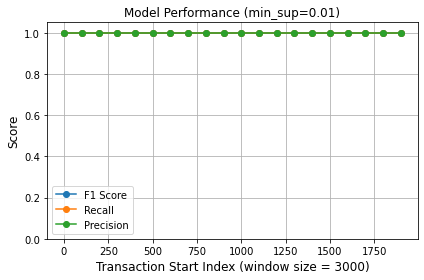

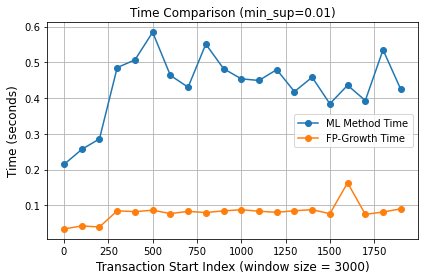

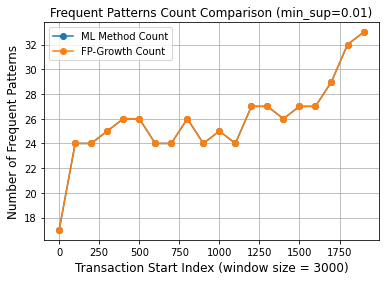

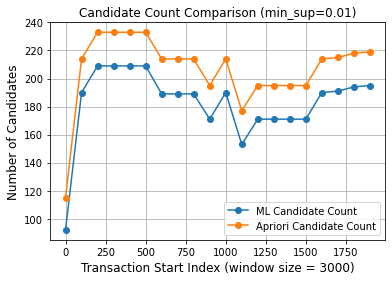

minsup=0.01, windows size = 3000, step size = 100, total windows = 20 (PROBA_THRESHOLD=0.0001, TOP_K=None)
step size 100, 24items, windows size1000'


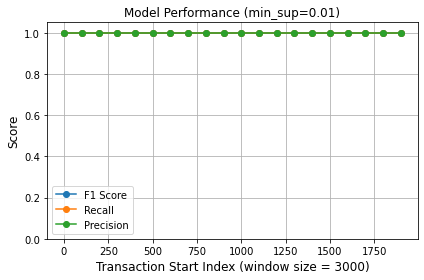

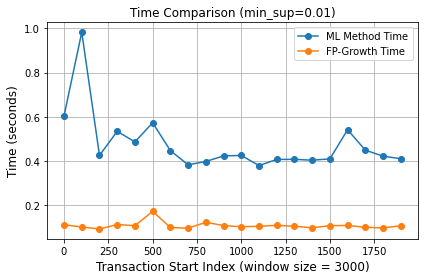

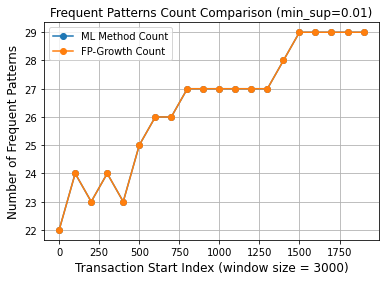

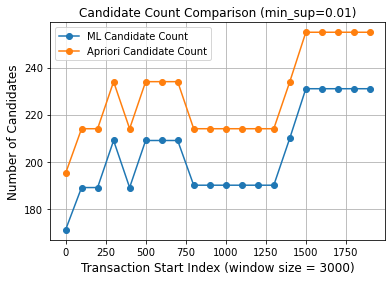

minsup=0.01, windows size = 3000, step size = 100, total windows = 20 (PROBA_THRESHOLD=0.0001, TOP_K=None)
step size 100, 24items, windows size2000'


In [99]:
# run all windows size



def run_all_windows_size(windows_size=5000, step_size=100, n_windows=20, min_support=0.1):
    """
    執行不同窗口大小的滑動窗口模擬，並返回結果 DataFrame。
    """
    print(f"Running sliding window with windows_size = {windows_size}...")

    results_df, streaming_results = run_sliding_window(
        artifact_filename=artifact_filename,
        min_support=min_support,
        start_offset=start_offset,
        window_size=windows_size,
        step_size=step_size,
        n_windows=n_windows,
        prob=PROBA_THRESHOLD,
        top_k=TOP_K
    )

    print(f"windows size = {windows_size}, step size = {step_size}, total windows = {n_windows} (PROBA_THRESHOLD={PROBA_THRESHOLD}, TOP_K={TOP_K})")

    # append avg to results_df
    avg_row = results_df.mean(numeric_only=True).to_frame().T
    avg_row = avg_row.round(6)
    avg_row['window_start'] = 'Average'
    results_df = pd.concat([results_df, avg_row], ignore_index=True)

    print(results_df.to_string(index=False))

    # save results to a CSV file
    results_df.to_csv(f'./data/stream_result/stream_results_{num_items}items_sup{min_support}_w{windows_size}.csv', index=False)
    print(f"Results saved to './data/stream_result/stream_results_{num_items}items_sup{min_support}_w{windows_size}.csv'")

    return results_df, streaming_results

all_results_df = {}
all_streaming_results = {}

windows_sizes = [1000,2000] #[4000,5000] #[1000, 2000, 3000, 4000, 5000]
for ws in windows_sizes:
    results_df, streaming_results = run_all_windows_size(windows_size=ws, step_size=STEP_SIZE, n_windows=N_WINDOWS_TO_RUN, min_support=0.1)
    all_results_df[ws] = results_df
    all_streaming_results[ws] = streaming_results
    print(f"\nResults for windows size = {ws}:\n{results_df}")


# plot all results 
# plot_results(results_df)
for ws, df in all_streaming_results.items():
    plot_results(df)
    print(f"step size {STEP_SIZE}, {num_items}items, windows size{ws}'")



### 用前1000訓練 後面測試

#### train model

In [22]:
import pickle
import time
import numpy as np
import pandas as pd
from collections import Counter
from itertools import combinations
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier

# -------------------------
# 1. 載入資料與設定
# -------------------------
num_items = 24  # 預設項目數
dataset_path = f'./data/dataset_{num_items}_items.csv'  # 修改路徑
df = pd.read_csv(dataset_path, sep='delimiter', header=None, engine='python')
txns = df[0].str.split(',').tolist()
txns = [[item.strip() for item in txn if item.strip() and item.strip() != '-1'] for txn in txns]

unique_items = sorted(set(i for t in txns for i in t))
item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
# num_items = len(unique_items)

print(f">> Loaded {len(txns)} transactions, {num_items} unique items.")


TRAIN_SIZE = 1000


# One-hot encoder for FP-Growth
te = TransactionEncoder()

# -------------------------
# 2. 特徵擷取
# -------------------------
def extract_features(prefix, node_count, child_counts):
    pv = np.zeros(num_items, int)
    for p in prefix:
        pv[p] = 1
    cc = np.zeros(num_items, int)
    for ch, ct in child_counts.items():
        cc[ch] = ct
    pc = node_count
    pl = len(prefix)
    p_bound = 0.0
    feat = np.concatenate([pv, cc, [pc], [pl], [p_bound]])
    return feat

# -------------------------
# 3. 模型訓練 (前1000筆)
# -------------------------
train_txns = txns[:TRAIN_SIZE]
features, labels = [], []
for txn in train_txns:
    codes = [item_to_idx[i] for i in txn]
    prefix = []
    for c in codes:
        feat = extract_features(prefix, node_count=len(train_txns), child_counts={})
        features.append(feat)
        labels.append(c)
        prefix.append(c)

X = np.array(features)
y = np.array(labels)

item_models = {}
for code in range(num_items):
    y_bin = (y == code).astype(int)
    if y_bin.sum() == 0:
        continue
    model = XGBClassifier(
        objective='binary:logistic',
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )
    model.fit(X, y_bin)
    item_models[code] = model

print(f">> Trained {len(item_models)} models using first {TRAIN_SIZE} transactions.")

# save the models
with open(f'{num_items}_item_models_{TRAIN_SIZE}.pkl', 'wb') as f:
    pickle.dump(item_models, f)
print(f">> Saved item models to {num_items}_item_models_{TRAIN_SIZE}.pkl")

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
c:\Users\zoezo\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:31:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


>> Loaded 7864 transactions, 24 unique items.


c:\Users\zoezo\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:31:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


>> Trained 22 models using first 1000 transactions.
>> Saved item models to 24_item_models_1000.pkl


#### function

In [212]:
def apriori_gen_for_streaming(transactions_in_window, min_support_threshold):
    """
    為滑動視窗模擬 Apriori 的候選集生成過程，並返回候選集數量。
    """
    if not transactions_in_window:
        return 0, []

    # 步驟 1: 找出第一層的頻繁樣式 (L1)
    item_counts = Counter(item for txn in transactions_in_window for item in txn)
    min_support_count = len(transactions_in_window) * min_support_threshold
    
    l1 = {frozenset([item]) for item, count in item_counts.items() if count >= min_support_count}
    
    if len(l1) < 2:
        return len(l1), list(l1) # 如果 L1 不足兩個，無法生成 C2

    # 步驟 2: 從 L1 生成第二層的候選集 (C2)
    # 這是傳統 Apriori 中計算開銷最大的候選集生成步驟
    c2 = {i.union(j) for i in l1 for j in l1 if len(i.union(j)) == 2}
    
    return len(c2), list(l1) # 返回 C2 的數量和 L1 的結果

import pandas as pd
from itertools import combinations

# --- 修正後的 Apriori 函式 ---

def create_C1(dataset):
    """創建大小為 1 的候選項目集 C1"""
    itemset = set()
    for transaction in dataset:
        for item in transaction:
            itemset.add(item)
    return [frozenset([item]) for item in sorted(list(itemset))]

def scan_D(D, Ck, min_support):
    """
    掃描資料集 D，從候選集 Ck 中計算出頻繁項目集 Lk 和支持度。
    """
    ss_cnt = {can: 0 for can in Ck}
    for tid in D:
        for can in Ck:
            if can.issubset(tid):
                ss_cnt[can] += 1
    
    num_items = float(len(D))
    Lk = []
    support_data = {}
    for key, count in ss_cnt.items():
        support = count / num_items
        if support >= min_support:
            Lk.append(key)
        support_data[key] = support
    return Lk, support_data

def apriori_gen(Lk_1, k):
    """
    從 L(k-1) 生成候選集 Ck (包含剪枝步驟的修正版)
    Lk_1: 大小為 k-1 的頻繁項目集列表
    k: 要生成的候選集大小
    """
    Ck = set()
    len_Lk_1 = len(Lk_1)
    
    # 1. 連接步驟 (Join Step)
    for i in range(len_Lk_1):
        for j in range(i + 1, len_Lk_1):
            L1 = list(Lk_1[i])
            L2 = list(Lk_1[j])
            L1.sort()
            L2.sort()
            # 如果前 k-2 個項目相同
            if L1[:k-2] == L2[:k-2]:
                Ck.add(Lk_1[i] | Lk_1[j]) # 取聯集得到大小為 k 的候選集

    # 2. 剪枝步驟 (Pruning Step)
    Ck_pruned = Ck.copy()
    for c in Ck:
        # 取得候選集 c 的所有大小為 k-1 的子集
        for subset in combinations(c, k - 1):
            # 如果任一子集不在 L(k-1) 中，則從候選集中移除 c
            if frozenset(subset) not in Lk_1:
                Ck_pruned.remove(c)
                break
                
    return list(Ck_pruned)

def apriori(dataset, min_support=0.5):
    """Apriori 主函式"""
    C1 = create_C1(dataset)
    D = list(map(set, dataset))
    L1, support_data = scan_D(D, C1, min_support)
    L = [L1]
    k = 2

    # 新增：儲存每層候選集數量的列表
    candidate_counts_per_level = [len(C1)] 
    
    while (len(L[k-2]) > 0):
        # 傳入 L(k-1) 來生成 Ck
        Ck = apriori_gen(L[k-2], k)

        # 收集當前層的候選集數量
        candidate_counts_per_level.append(len(Ck))

        if not Ck:
            break
        Lk, supK = scan_D(D, Ck, min_support)
        support_data.update(supK)
        L.append(Lk)
        k += 1
    return L, support_data, candidate_counts_per_level

def run_my_apriori_stream(window_txns, min_support=0.1):
    apr_start_time = time.time()
    # print(f"Running Apriori with min_support = {min_support}...")

    # 載入資料
    # df = pd.read_csv(dataset, sep='delimiter', header=None, engine='python')
    # txns = df[0].str.split(',').tolist()
    # txns = [
    #     [item.strip() for item in txn if item.strip() and item.strip() != '-1']
    #     for txn in txns
    # ]
    # txns = txns[:int(len(txns))* dataset_prct]
    
    # 給該視窗的資料
    # 執行 Apriori
    L, support_data, candidate_counts_per_level = apriori(window_txns, min_support=min_support)
    
    # 整理並輸出結果
    all_frequent_itemsets = [item for sublist in L for item in sublist]
    my_aprior_frequent_itemsets = sorted(all_frequent_itemsets, key=lambda x: (len(x), support_data[x]), reverse=True)
    # print(f"\nFound {len(my_aprior_frequent_itemsets)} frequent itemsets in total.")

    # 輸出前幾個頻繁項目集及其支持度
    # for itemset in all_frequent_itemsets[:10]:
    #     print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    # print the count by length
    length_counter = Counter(len(itemset) for itemset in my_aprior_frequent_itemsets)
    # print("\nFrequent itemsets by length:")
    # for length, count in sorted(length_counter.items()):
        # print(f"Length {length}: {count} itemsets")
        

    apr_end_time = time.time()

    # print(f"Pure Python Apriori finished in {apr_end_time - apr_start_time:.2f} seconds.")

    # print length=5
    # for itemset in my_aprior_frequent_itemsets:
    #     if len(itemset) == 5:
    #         print(f"Itemset: {list(itemset)}, Support: {support_data[itemset]:.4f}")

    # 計算 Apriori 需要驗證的候選集總數
    total_apriori_candidates = sum(candidate_counts_per_level)
    
    # print(f"Pure Python Apriori generated a total of {total_apriori_candidates} candidates to validate.")
    

    return my_aprior_frequent_itemsets, support_data, apr_end_time - apr_start_time, total_apriori_candidates

def validate_candidate_batch(candidates_to_check, transactions, min_support_threshold):
    """
    批次驗證，一次掃描資料庫，計算所有候選樣式的支持度。
    
    參數:
    candidates_to_check (set or list): 包含所有待驗證候選樣式（tuple）的集合或列表。
    transactions (list of sets): 當前視窗的交易數據。
    min_support_threshold (float): 最小支持度門檻。
    
    返回:
    frequent_patterns (dict): 一個字典，key 是通過驗證的頻繁樣式tuple ，value 是它們的支持度。
    """
    if not candidates_to_check:
        return {}

    # 1. 為所有候選樣式初始化計數器
    support_counts = {tuple(sorted(cand)): 0 for cand in candidates_to_check}
    
    start_time = time.time()
    # 2. 對交易數據庫只進行一次完整遍歷
    for txn_set in transactions:
        for candidate_tuple in support_counts.keys():
            # 使用 frozenset 進行子集檢查效率稍高
            if frozenset(candidate_tuple).issubset(txn_set):
                support_counts[candidate_tuple] += 1

    # 3. 根據支持度門檻篩選出真正的頻繁樣式
    total_txns = len(transactions)
    min_support_count = total_txns * min_support_threshold
    frequent_patterns = {}
    for pattern, count in support_counts.items():
        if count >= min_support_count:
            frequent_patterns[pattern] = count / total_txns

    all_time = time.time() - start_time
            
    return frequent_patterns, all_time

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [47]:

def validate_candidate_batch_plus(candidates_to_check, transactions, min_support_threshold):
    """
    批次驗證，一次掃描資料庫，計算所有候選樣式的支持度。
    
    參數:
    candidates_to_check (set or list): 包含所有待驗證候選樣式（tuple）的集合或列表。
    transactions (list of sets): 當前視窗的交易數據。
    min_support_threshold (float): 最小支持度門檻。
    
    返回:
    frequent_patterns (dict): 一個字典，key 是通過驗證的頻繁樣式tuple ，value 是它們的支持度。
    """
    if not candidates_to_check:
        return {}

    # 1. 為所有候選樣式初始化計數器
    # support_counts = {tuple(sorted(cand)): 0 for cand in candidates_to_check}
    
    # 在迴圈外，一次性將所有候選集轉為 frozenset ***
    # 這裡的 key 現在是 frozenset
    support_counts = {frozenset(cand): 0 for cand in candidates_to_check}

    validate_start = time.time()
    
    # 2. 對交易數據庫只進行一次完整遍歷
    for txn_set in transactions:
        
        # for candidate_tuple in support_counts.keys():
            # 使用 frozenset 進行子集檢查效率稍高
            # if frozenset(candidate_tuple).issubset(txn_set):
            #     support_counts[candidate_tuple] += 1

        # # 直接迭代 frozenset，不再有內部轉換 ***
        for candidate_frozenset in support_counts.keys():
            if candidate_frozenset.issubset(txn_set):
                support_counts[candidate_frozenset] += 1

    # 3. 根據支持度門檻篩選出真正的頻繁樣式
    total_txns = len(transactions)
    min_support_count = total_txns * min_support_threshold
    frequent_patterns = {}
    
    # for pattern, count in support_counts.items():
    #     if count >= min_support_count:
    #         frequent_patterns[pattern] = count / total_txns
    
    # ***
    for pattern_frozenset, count in support_counts.items():
        if count >= min_support_count:
            # 轉回 tuple 作為 key
            frequent_patterns[tuple(sorted(pattern_frozenset))] = count / total_txns

    validate_end = time.time()
    validate_time = validate_end - validate_start
            
    return frequent_patterns, validate_time


def validate_candidate_batch(candidates_to_check, transactions, min_support_threshold):
    """
    批次驗證，一次掃描資料庫，計算所有候選樣式的支持度。
    
    參數:
    candidates_to_check (set or list): 包含所有待驗證候選樣式（tuple）的集合或列表。
    transactions (list of sets): 當前視窗的交易數據。
    min_support_threshold (float): 最小支持度門檻。
    
    返回:
    frequent_patterns (dict): 一個字典，key 是通過驗證的頻繁樣式tuple ，value 是它們的支持度。
    """
    if not candidates_to_check:
        return {}

    # 1. 為所有候選樣式初始化計數器
    support_counts = {tuple(sorted(cand)): 0 for cand in candidates_to_check}
    
    # 在迴圈外，一次性將所有候選集轉為 frozenset ***
    # 這裡的 key 現在是 frozenset
    # support_counts = {frozenset(cand): 0 for cand in candidates_to_check}

    validate_start = time.time()
    
    # 2. 對交易數據庫只進行一次完整遍歷
    for txn_set in transactions:
        
        for candidate_tuple in support_counts.keys():
            # 使用 frozenset 進行子集檢查效率稍高
            if frozenset(candidate_tuple).issubset(txn_set):
                support_counts[candidate_tuple] += 1

        # # # 直接迭代 frozenset，不再有內部轉換 ***
        # for candidate_frozenset in support_counts.keys():
        #     if candidate_frozenset.issubset(txn_set):
        #         support_counts[candidate_frozenset] += 1

    # 3. 根據支持度門檻篩選出真正的頻繁樣式
    total_txns = len(transactions)
    min_support_count = total_txns * min_support_threshold
    frequent_patterns = {}
    
    for pattern, count in support_counts.items():
        if count >= min_support_count:
            frequent_patterns[pattern] = count / total_txns
    
    # ***
    # for pattern_frozenset, count in support_counts.items():
    #     if count >= min_support_count:
    #         # 轉回 tuple 作為 key
    #         frequent_patterns[tuple(sorted(pattern_frozenset))] = count / total_txns

    validate_end = time.time()
    validate_time = validate_end - validate_start
            
    return frequent_patterns, validate_time

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### data stream

In [ ]:
MIN_SUPPORT = 0.09 #0.1
# N_windows = 400
N_windows = 10 #40  # 處理的窗口數量
TOP_K = None # 10 #5 # 模型在每個擴展步驟中考慮的最佳選項數量
PROBA_THRESHOLD = 0.01 #0.03 #0.01 # 模型預測機率的過濾門檻

WINDOW_SIZE = 6000 #6000 #3000 #100
STEP_SIZE = 10

length_dist_list = []  # 用於收集每個窗口的長度分佈
total_candidates_generated = 0
# -------------------------
# 4. Data Stream 預測擴展
# -------------------------
results = []

# import pickle
# num_items = 12
# TRAIN_SIZE = 1000  # 訓練集大小

start_idx = TRAIN_SIZE
# end_idx = TRAIN_SIZE + (WINDOW_SIZE + STEP_SIZE * 4)  # 跑5個窗口
# end_idx = TRAIN_SIZE + (WINDOW_SIZE + STEP_SIZE * 41)  # 跑50個窗口
# end_idx = TRAIN_SIZE + STEP_SIZE * 40  # 只跑40個窗口
end_idx = TRAIN_SIZE + STEP_SIZE * N_windows  # 只跑N個窗口

# from pkl import item_models
with open(f'{num_items}_item_models_{TRAIN_SIZE}.pkl', 'rb') as f:
    item_models = pickle.load(f)



for idx in range(start_idx, end_idx, STEP_SIZE):
    generate_times = 0
    validate_times = 0  
    window_txns = txns[idx: idx + WINDOW_SIZE]

    # --- 模型擴展 ---
    generated_patterns = set()
    queue = [()]  # 從空prefix開始

    # 用於儲存每一層的頻繁樣式，以便進行 Apriori 剪枝
    frequent_patterns_per_level = {1: set()} 

    

    # 驗證第一層 (L1)
    item_counts = Counter(item for txn in window_txns for item in txn)
    min_support_count = len(window_txns) * MIN_SUPPORT

    t0 = time.time()

    l1 = {frozenset([item]) for item, count in item_counts.items() if count >= min_support_count}
    frequent_patterns_per_level[1] = {tuple(sorted(p)) for p in l1}

    validate_time = time.time() - t0
    validate_times += validate_time
    
    # generated_patterns 存儲所有最終通過驗證的頻繁樣式
    generated_patterns = {tuple(sorted(p)) for p in l1}
    # queue 用於廣度優先搜索，只存儲上一層的頻繁樣式
    queue = list(frequent_patterns_per_level[1])
    
    # 總候選集計數器
    total_candidates_generated = len(l1)

    current_length = 2
    while queue:
        # 暫存下一層的頻繁樣式
        next_level_frequent = set()
        
        # 暫存下一層的候選樣式 (在 Apriori 剪枝前)
        next_level_candidates_before_pruning = set()

        start_generate_time = time.time()

        for prefix_tuple in queue:
            prefix = list(prefix_tuple)
            feat = extract_features([item_to_idx[i] for i in prefix], node_count=WINDOW_SIZE, child_counts={})
            scores = []
            for code, model in item_models.items():
                if unique_items[code] in prefix:
                    continue
                prob = model.predict_proba([feat])[0][1]
                scores.append((code, prob))
            
            if TOP_K is not None:
                scores = sorted(scores, key=lambda x: x[1], reverse=True)[:TOP_K]

            for code, prob in scores:
                # 1. 機率過濾 (Probability Filtering)
                if prob < PROBA_THRESHOLD:
                    continue

                new_candidate = tuple(sorted(prefix + [unique_items[code]]))
                
                # 只在第一次遇到時才計為候選
                if new_candidate not in next_level_candidates_before_pruning:
                    next_level_candidates_before_pruning.add(new_candidate)
        
        # 在生成完所有潛在候選後，進行內部剪枝
        pruned_candidates = set()
        if current_length > 2: #> 2: # 剪枝只對長度 > 2 的樣式有效
            for candidate in next_level_candidates_before_pruning:
                is_valid = True
                # 檢查所有 k-1 子集是否都在上一層的頻繁集中
                for subset in combinations(candidate, current_length - 1):
                    if tuple(sorted(subset)) not in frequent_patterns_per_level[current_length - 1]:
                        is_valid = False
                        break
                if is_valid:
                    pruned_candidates.add(candidate)
        else: # 長度為 2 的候選無需剪枝
            pruned_candidates = next_level_candidates_before_pruning
        # pruned_candidates = next_level_candidates_before_pruning
        
        total_candidates_generated += len(pruned_candidates)

        generate_time = time.time() - start_generate_time

        # vali_start_time = time.time()   
        # 只驗證通過剪枝的候選集
        # for new_prefix in pruned_candidates:
        #     support = sum(1 for t in window_txns if set(new_prefix).issubset(t)) / len(window_txns)
        #     if support >= MIN_SUPPORT:
        #         generated_patterns.add(new_prefix)
        #         next_level_frequent.add(new_prefix)

        total_candidates_generated += len(pruned_candidates)
        
        if not pruned_candidates:
            break
            
        # --- 3. 關鍵修正：呼叫高效的批次驗證函數 ---
        # vali_start_time = time.time()   
        newly_frequent_dict, validate_time = validate_candidate_batch_plus(
            pruned_candidates, 
            window_txns, 
            MIN_SUPPORT
        )
        # print(f'window: {idx}: {validate_time:.2f} seconds for validation of {len(pruned_candidates)} candidates.')
        # validate_time = time.time() - vali_start_time
        # print(f'window: {idx}: {validate_time:.2f} seconds for validation of {len(pruned_candidates)} candidates.')


        
        # if not next_level_frequent:
        if not newly_frequent_dict:
            break
        
        # 準備下一輪
        next_level_frequent = set(newly_frequent_dict.keys())
        frequent_patterns_per_level[current_length] = next_level_frequent
        queue = list(next_level_frequent)
        current_length += 1


        validate_times += validate_time
        generate_times += generate_time

    validate_times = round(validate_times, 2)
    generate_times = round(generate_times, 2)
    # latency = time.time() - t0
    latency = validate_times + generate_times
    # 只要小數點後兩位
    # latency = round(latency, 2)

    

    # print(f"Window {idx}:")
    # print("Predicted Patterns:", generated_patterns)

    length_dist = Counter(len(p) for p in generated_patterns)
    print(f"Window {idx} Length Distribution {length_dist}")
    # length_dist_list 收集每個窗口的 Counter
    length_dist_list.append(length_dist)

    # --- FP-Growth 基準 ---
    fpg_start_time = time.time()
    w_df = pd.DataFrame(te.fit(window_txns).transform(window_txns), columns=te.columns_)
    fp_growth_patterns = fpgrowth(w_df, min_support=MIN_SUPPORT, use_colnames=True)
    ground_truth = set([tuple(sorted(itemset)) for itemset in fp_growth_patterns['itemsets']])
    fpg_latency = time.time() - fpg_start_time
    fpg_latency = round(fpg_latency, 2)

    # --- apriori candidate count and time---
    # apriori_cand_count, _ = apriori_gen_for_streaming(window_txns, MIN_SUPPORT)
    # apr_start_time = time.time()
    # 使用純 Python 的 Apriori 方法

    my_aprior_frequent_itemsets, apr_support_data, aprior_time, apriori_cand_count = run_my_apriori_stream(window_txns, min_support=MIN_SUPPORT)

    # apr_end_time = time.time()
    # apr_time = round(apr_end_time - apr_start_time, 2)
    apr_time = round(aprior_time, 2)
    print(f"apriori results: {len(my_aprior_frequent_itemsets)} patterns found in {apr_time} seconds.")

    
    # --- 評估 ---
    TP = len(generated_patterns & ground_truth)
    FP = len(generated_patterns - ground_truth)
    FN = len(ground_truth - generated_patterns)
    precision = TP / (TP + FP) if TP + FP > 0 else 0
    recall = TP / (TP + FN) if TP + FN > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'window': idx,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        
        'generate': generate_times,
        'validate': validate_times,
        'ml_time': latency,
        'fpg_time': fpg_latency,
        'apr_time': apr_time,

        'apriori_cand': apriori_cand_count,
        'ml_candidate': total_candidates_generated, # ML 方法生成的候選集數量

        'num_generated': len(generated_patterns), # ML 方法生成的樣式數量
        'num_ground_truth': len(ground_truth) # fp growth 的頻繁樣式數量
    })

stream_df = pd.DataFrame(results)
print("\n=== Streaming Results ===")
# print(stream_df)
print(stream_df.to_string())


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Window 1000 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.23 seconds.
Window 1010 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.2 seconds.
Window 1020 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.18 seconds.
Window 1030 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.29 seconds.
Window 1040 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.17 seconds.
Window 1050 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.15 seconds.
Window 1060 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.15 seconds.
Window 1070 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.16 seconds.
Window 1080 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.16 seconds.
Window 1090 Length Distribution Counter({1: 22})
apriori results: 28 patterns found in 0.14 

#### save result to csv

In [18]:
# 之後要加上時間記錄與比較
print(stream_df.to_string())
# save results to CSV
stream_df.to_csv(f'./data/streaming_w{WINDOW_SIZE}_sup{MIN_SUPPORT}_{TOP_K}_{PROBA_THRESHOLD}.csv', index=False)
print(f"results saved to ./data/streaming_results_w{WINDOW_SIZE}_sup{MIN_SUPPORT}_{TOP_K}_{PROBA_THRESHOLD}.csv")
# total data number
total_data_number = len(txns)
print(f"Total data number: {total_data_number}")

    window  TP  FP  FN  precision  recall   f1  latency_sec  fpg_latency_sec  apriori_cand_count  ml_candidate_count  num_generated  num_ground_truth
0     1000  18   0   0        1.0     1.0  1.0         0.37             0.15                  66                  55             18                18
1     1010  17   0   0        1.0     1.0  1.0         0.27             0.15                  66                  55             17                17
2     1020  17   0   0        1.0     1.0  1.0         0.31             0.24                  66                  55             17                17
3     1030  18   0   0        1.0     1.0  1.0         0.65             0.16                  66                  55             18                18
4     1040  17   0   0        1.0     1.0  1.0         0.36             0.14                  66                  55             17                17
5     1050  17   0   0        1.0     1.0  1.0         0.35             0.14                  66    

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### visual

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


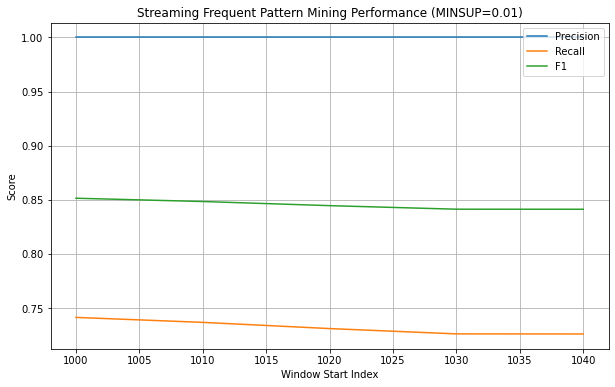

Figure saved to ./figures/stream_w100_minsup_0.01.png


<Figure size 432x288 with 0 Axes>

In [36]:

# 可視化
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
# plt.plot(stream_df['window'], stream_df['precision'], marker='o', label='Precision')
# plt.plot(stream_df['window'], stream_df['recall'], marker='s', label='Recall')
# plt.plot(stream_df['window'], stream_df['f1'], marker='^', label='F1')
plt.plot(stream_df['window'].values, stream_df['precision'].values, marker='', label='Precision') # marker='x' cross
plt.plot(stream_df['window'].values, stream_df['recall'].values, marker='', label='Recall') # marker='s' square
plt.plot(stream_df['window'].values, stream_df['f1'].values, marker='', label='F1') # marker='^' triangle, marker='o' circle


plt.title(f'Streaming Frequent Pattern Mining Performance (MINSUP={MIN_SUPPORT})')
plt.xlabel('Window Start Index')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig(f'./figures/stream_w{WINDOW_SIZE}_minsup_{MIN_SUPPORT}.png')
print(f"Figure saved to ./figures/stream_w{WINDOW_SIZE}_minsup_{MIN_SUPPORT}.png")
# _w{WINDOW_SIZE}_sup{MIN_SUPPORT}_{TOP_K}_{PROBA_THRESHOLD}

In [ ]:
import matplotlib.pyplot as plt

# 假設 length_dist_list 收集每個窗口的 Counter
avg_dist = Counter()
for dist in length_dist_list:
    for k, v in dist.items():
        avg_dist[k] += v
for k in avg_dist:
    avg_dist[k] /= len(length_dist_list)

plt.bar(avg_dist.keys(), avg_dist.values())
plt.xlabel('Pattern Length')
plt.ylabel('Average Count')
plt.title('Average Frequent Pattern Length Distribution')
plt.show()


## get result and plot

#### get result

In [ ]:
import pickle
def run_one_support(MIN_SUPPORT = 0.1, dataset_prct=1.0, dataset=''):
    # print("Loading model artifacts for hybrid generation...")
    with open(f'fp_model_artifacts_{num_items}.pkl', 'rb') as f:
        loaded_artifacts = pickle.load(f)

    # MIN_SUPPORT = 0.01 # 0.1 # 0.05 
    # dataset_prct = 1.0

    # 執行混合式生成
    final_patterns_with_duplicates, total_generate_time, total_validation_time, len_ml_candidates = run_hybrid_generation(
    # final_patterns_with_duplicates, total_generate_time, total_validation_time = run_hybrid_generations(
        artifacts=loaded_artifacts,
        min_support_threshold=MIN_SUPPORT, # 0.1, 0.05, 0.01
        dataset_prct=dataset_prct,  # 使用 80% 的訓練集進行驗證
        top_k_expansion=None,  
        # top_k_expansion=5, # 每次擴展時，考慮排名前 5 的預測 top l expansions
        proba_threshold = 0.01, #1e-5, #0.01 
        dataset=dataset  # 指定交易數據集路徑
    )
    
    final_unique_patterns = {}
    for pattern_tuple, support in final_patterns_with_duplicates.items():
        # 將樣式轉換為 排序後的 tuple
        canonical_pattern = tuple(sorted(pattern_tuple))

        if canonical_pattern not in final_unique_patterns or support > final_unique_patterns[canonical_pattern][1]:
            final_unique_patterns[canonical_pattern] = (pattern_tuple, support)

    
    # 將結果解碼並按長度和支持度排序
    decoded_results = []
    enc = loaded_artifacts['encoder']
    # for p_codes, support in final_unique_patterns.items():
    for p_codes, support in final_unique_patterns.values():
        decoded_results.append({
            "pattern": enc.inverse_transform(list(p_codes)).tolist(),
            "support": support
        })
    
    decoded_results.sort(key=lambda x: (len(x['pattern']), x['support']), reverse=True)

    # 最後輸出總結
    print("\n--- Final Summary ---", MIN_SUPPORT, dataset_prct, dataset)
    print(f"Total unique patterns discovered: {len(final_unique_patterns)}, \n generate time: {total_generate_time:.2f} seconds")
    print(f"validation time: {total_validation_time:.2f} seconds, \n Total time for hybrid generation: {total_generate_time + total_validation_time:.2f} seconds")
    # by length
    length_counter = Counter(len(item['pattern']) for item in decoded_results)
    print("Pattern lengths distribution:")  
    for length, count in sorted(length_counter.items()):
        print(f"  Length {length}: {count} patterns")

    # FP Growth 
    start_time_fp = time.time()
    fp_results = run_fp_growth(min_support_threshold=MIN_SUPPORT)
    end_time_fp = time.time()
    fp_validation_time = end_time_fp - start_time_fp
    print(f"FP-Growth: {len(fp_results)} in {fp_validation_time:.2f} seconds (min_sup = {MIN_SUPPORT}, [{dataset_prct}]*{dataset}.")
    
    ## COMPARE
    # fp_results 是您從 run_fp_growth 得到的 DataFrame
    print("min_support_threshold:", MIN_SUPPORT)
    # 計算每個樣式的長度
    fp_results['length'] = fp_results['itemsets'].apply(lambda x: len(x))
    # 按長度統計數量
    fp_length_counts = fp_results['length'].value_counts().sort_index()
    print("\n--- FP-Growth Pattern Counts by Length ---")
    print(fp_length_counts)

    ## compare ML and FP-Growth results
    final_ml_fps = final_unique_patterns
    # 將這個結果與 ML 方法找到的96個樣式的長度分佈做比較
    ml_patterns_df = pd.DataFrame({'itemsets': final_ml_fps.keys()})
    ml_patterns_df['length'] = ml_patterns_df['itemsets'].apply(len)
    ml_length_counts = ml_patterns_df['length'].value_counts().sort_index()

    print("\n--- ML Method Pattern Counts by Length ---")
    print(ml_length_counts)
    # tp, tn, fp, fn = calculate_tp_tn_fp_fn(ml_patterns=final_fps.keys(), fp_patterns=fp_results['itemsets'])
    tp, tn, fp, fn = calculate_tp_tn_fp_fn_with_encoder(ml_patterns_codes=final_ml_fps.keys(), 
                                                    fp_patterns_names=fp_results['itemsets'].tolist(),
                                                    encoder=loaded_artifacts['encoder'])
    print_tp_tn_fp_fn(tp, tn, fp, fn)
    # precision, recall, f1_score
    p, r,f1 = calculate_print_precision_recall_f1(tp, fp, fn)

    # aprior
    _, _, aprior_time, len_apriori_candidates = run_my_apriori(dataset, min_support=MIN_SUPPORT, dataset_prct=dataset_prct)

    ml_count = len(final_ml_fps)


    return (p, r, f1, fp_validation_time, total_generate_time + total_validation_time, 
            len(fp_results), aprior_time, ml_count, len_apriori_candidates, len_ml_candidates)

    

if __name__ == '__main__':
    # 測試不同的支持度

    dataset_prct = 1.0 #1.0 # 使用 100% 的資料
    num_items = '36'  # 商品數量
    dataset = f'./data/dataset_{num_items}_items.csv'  # 交易數據集

    f1_all, precision_all, recall_all = [], [], []
    pattern_count_all, pattern_count_all_ml = [], []
    fpg_times, ml_total_times, aprior_times = [], [], []
    len_ml_candidates, len_apriori_candidates = [], []

    for min_support in [0.11, 0.09, 0.07, 0.05, 0.03, 0.01]:
        print(f"\n--- Running with MIN_SUPPORT = {min_support} ---")
        
        p, r, f1, fp_time, ml_total_time, fp_count, aprior_time, ml_count, len_apriori_candidate, len_ml_candidate = run_one_support(MIN_SUPPORT=min_support, dataset_prct=dataset_prct, dataset=dataset)
        f1_all.append(f1)
        precision_all.append(p)
        recall_all.append(r)

        fpg_times.append(fp_time)
        ml_total_times.append(ml_total_time)

        # if min_support == 0.01:
        #     aprior_times.append(0)  # 最小支持度為 0.01 時不執行 Apriori
        # else:
        #     aprior_times.append(aprior_time) 
        aprior_times.append(aprior_time)

        pattern_count_all.append(fp_count)
        pattern_count_all_ml.append(ml_count)
        len_apriori_candidates.append(len_apriori_candidate)
        len_ml_candidates.append(len_ml_candidate)

    print(f"\n--- Summary of Results --- (dataset: {dataset}, dataset_prct: {dataset_prct})")
    # print(f"{'MIN_SUPPORT':<15} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'FP-Growth Time':<20} {'ML Total Time':<20} {'Aprior Time':<20} {'FP Count':<15} {'ML Count':<15} {'Apriori Candidates':<20} {'ML Candidates':<20}")

    print(f"{'MIN_SUPPORT':<15} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'FP-Growth(s)':<15} {'ML Total(s)':<15} {'Aprior(s))':<15} {'FP Count':<10} {'ML Count':<10} {'Apriori Candidates':<10} {'ML Candidates':<10}")
    for min_support, p, r, f1, fp_time, ml_time, aprior_time, fpg_count, ml_count, len_apriori_can, len_ml_can in zip(
        [0.11, 0.09, 0.07, 0.05, 0.03, 0.01],
        precision_all, recall_all, f1_all,
        fpg_times, ml_total_times, aprior_times,
        pattern_count_all, pattern_count_all_ml,
        len_apriori_candidates, len_ml_candidates
    ):
        print(f"{min_support:<15} {p:<10.4f} {r:<10.4f} {f1:<10.4f} {fp_time:<10.2f} {ml_time:<10.2f} {aprior_time:<10.2f}{fpg_count:<10}{ml_count:<10}{len_apriori_can:<10}{len_ml_can:<10}")



c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)



--- Running with MIN_SUPPORT = 0.11 ---
this version does NOT keep same patterns in different orders
--- Level 1: Validating single items --- (minimum support threshold = 0.11)
Found 23 frequent patterns with support >= 0.11 in 9677 transactions.
Validation ratio: 63.89%: 23/36
not selected 13 patterns support: avg=0.0915, max=0.1096, min=0.0621, median=0.0937
selected 23 patterns support: avg=0.1435, max=0.2575, min=0.1101, median=0.1245

--- Level 2: Generating candidates from 23 frequent patterns ---
Generated 805 feature vectors for Level 2.
top-k_expansion: None, proba_threshold: 0.01
Generated 536 candidates for Level 2 with probability > 0.01.
After Apriori pruning, 254 candidates remain.
Generated 536 ordered candidates, which resulted in 247 unique sets for validation.
Found 0 frequent patterns with support >= 0.11 in 9677 transactions.
Validation ratio: 0.00%: 0/247
not selected 247 patterns support: avg=0.0290, max=0.0999, min=0.0083, median=0.0251
Validation completed for 

##### summary

In [56]:
print(f"\n--- Summary of Results --- (dataset: {dataset}, dataset_prct: {dataset_prct})")
# print(f"{'MIN_SUPPORT':<15} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'FP-Growth Time (s)':<20} {'ML Total Time (s)':<20} {'Aprior Time (s)':<20} {'Pattern Count':<15}")

print(f"{'MINSUP':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'FP-Growth(s)':<15} {'ML Total(s)':<15} {'Aprior(s)':<14} {'FP Count':<12} {'ML Count':<10} {'Apriori Can':<12} {'ML Candidates':<15}")
for min_support, p, r, f1, fp_time, ml_time, aprior_time, fpg_count, ml_count, len_apriori_can, len_ml_can in zip(
    [0.11, 0.09, 0.07, 0.05, 0.03, 0.01],
    precision_all, recall_all, f1_all,
    fpg_times, ml_total_times, aprior_times,
    pattern_count_all, pattern_count_all_ml,
    len_apriori_candidates, len_ml_candidates
):
    print(f"{min_support:<10} {p:<10.4f} {r:<10.4f} {f1:<10.4f} {fp_time:<15.2f} {ml_time:<15.2f} {aprior_time:<15.2f}{fpg_count:<12}{ml_count:<10}{len_apriori_can:<12}{len_ml_can:<15}")


# save results to a CSV file
import pandas as pd
results_df = pd.DataFrame({
    'MIN_SUPPORT': [0.11, 0.09, 0.07, 0.05, 0.03, 0.01],
    # 'Precision': precision_all, 
    # 'Recall': recall_all,
    # 'F1 Score': f1_all,
    # 'FP-Growth(s)': fpg_times,
    # 'ML Total(s)': ml_total_times,
    # 'Aprior(s)': aprior_times,
    # # 取小數點後四位
    'Precision': [f"{p:.4f}" for p in precision_all],
    'Recall': [f"{r:.4f}" for r in recall_all],
    'F1 Score': [f"{f1:.4f}" for f1 in f1_all],
    'FP-Growth(s)': [f"{fp:.2f}" for fp in fpg_times],
    'ML Total(s)': [f"{ml:.2f}" for ml in ml_total_times],
    'Aprior(s)': [f"{apr:.2f}" for apr in aprior_times],
    'FP Count': pattern_count_all,
    'ML Count': pattern_count_all_ml,
    'Apriori Candidates': len_apriori_candidates,
    'ML Candidates': len_ml_candidates
})

mynote = "_thershold_0.01_prun" #1e-5" # 顯示 threshold

results_df.to_csv(f'./data/results_{num_items}_items{mynote}.csv', index=False)
print(f"\nResults saved to results_{num_items}_items{mynote}.csv")

#####
# MINSUP     Precision  Recall     F1 Score   FP-Growth(s)    ML Total(s)     Aprior(s)      FP Count     ML Count   Apriori Can  ML Candidates  
# 0.11       1.0000     1.0000     1.0000     0.14            0.29            0.07           14          14        55          95             
# 0.09       1.0000     1.0000     1.0000     0.33            0.29            0.12           19          19        68          119            
# 0.07       1.0000     1.0000     1.0000     0.42            0.44            0.13           27          27        77          161            
# 0.05       1.0000     1.0000     1.0000     0.72            0.40            0.11           43          43        104         209            
# 0.03       1.0000     1.0000     1.0000     1.12            0.46            0.34           78          78        214         244            
# 0.01       1.0000     0.8195     0.9008     5.40            1.10            0.44           338         277       449         547            

# Results saved to results_12_items_thershold_1e-5.csv

# --- Summary of Results --- (dataset: ./data/dataset_12_items.csv, dataset_prct: 1.0)
# MINSUP     Precision  Recall     F1 Score   FP-Growth(s)    ML Total(s)     Aprior(s)      FP Count     ML Count   Apriori Can  ML Candidates  
# 0.11       1.0000     1.0000     1.0000     0.14            0.21            0.07           14          14        55          88             
# 0.09       1.0000     1.0000     1.0000     0.25            0.30            0.16           19          19        68          111            
# 0.07       1.0000     1.0000     1.0000     0.26            0.30            0.08           27          27        77          153            
# 0.05       1.0000     0.9767     0.9882     0.53            0.35            0.08           43          42        104         196            
# 0.03       1.0000     0.9231     0.9600     0.96            0.43            0.14           78          72        203         226            
# 0.01       1.0000     0.7426     0.8523     4.58            0.76            0.33           338         251       394         477  


--- Summary of Results --- (dataset: ./data/dataset_36_items.csv, dataset_prct: 1.0)
MINSUP     Precision  Recall     F1 Score   FP-Growth(s)    ML Total(s)     Aprior(s)      FP Count     ML Count   Apriori Can  ML Candidates  
0.11       1.0000     1.0000     1.0000     0.28            1.03            0.37           23          23        289         247            
0.09       1.0000     1.0000     1.0000     0.68            1.52            0.89           33          33        501         454            
0.07       1.0000     1.0000     1.0000     0.62            1.16            0.76           41          41        597         546            
0.05       1.0000     1.0000     1.0000     1.17            1.49            1.07           68          68        686         626            
0.03       1.0000     0.9464     0.9725     3.16            1.72            0.80           168         159       839         750            
0.01       1.0000     0.7395     0.8502     45.49           8.84 

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


##### plot time and dataset distribute

In [215]:
# fp time, ml time
# 36item:86.06912899017334,28.371309518814087
# 24item: 72.02561020851135,14.251404285430908
# 12item: 6.568248987197876,0.79318237304687
# 12eitem: 72,11

# ml time比fp time快多少倍?
item36 = 86.06912899017334 / 28.371309518814087
item24 = 72.02561020851135 / 14.251404285430908
item12 = 6.568248987197876 / 0.793182373046
item12e = 72 / 11
print(f"36 items: {item36:.2f} times faster")
print(f"24 items: {item24:.2f} times faster")   
print(f"12 items: {item12:.2f} times faster")
print(f"12e items: {item12e:.2f} times faster")

# avg
print(f"Average: {(item36 + item24 + item12 + item12e) / 4:.2f} times faster")

# 之後可以算候選集數量是否較少
# 、模型Top-K 正確率與實際支撐度驗證
# 透過回掃原始資料對候選集做支持度過濾後，Precision 恆為 100%；候選集大小僅為 FP-Growth 輸出樣式總數的 8–15%，有效降低後續分析負擔。

36 items: 3.03 times faster
24 items: 5.05 times faster
12 items: 8.28 times faster
12e items: 6.55 times faster
Average: 5.73 times faster


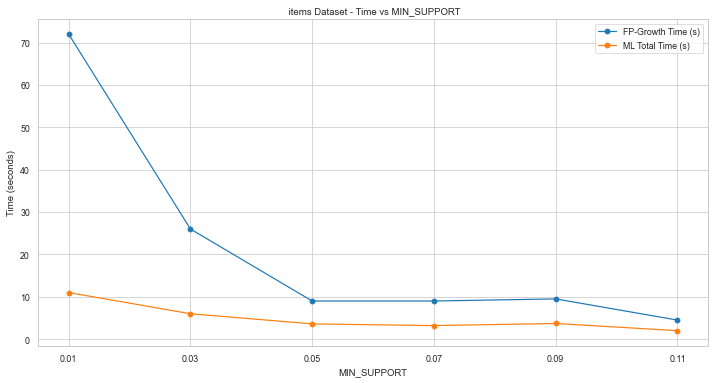

In [212]:
# draw time
# ml_total_times = [0.42, 0.59, 0.58, 0.63, 0.60, 0.79]
fpg_times=[72, 26,9,9,9.5,4.5]
ml_total_times=[11,6, 3.6, 3.2, 3.7, 2]
# reverse the order for plotting
fpg_times.reverse()
ml_total_times.reverse()
plt.figure(figsize=(12, 6))
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], fpg_times, marker='o', label='FP-Growth Time (s)')
plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], ml_total_times, marker='o', label='ML Total Time (s)')
# plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], aprior_times, marker='o', label='Apriori Time (s)')
plt.title(f'{num_items} items Dataset - Time vs MIN_SUPPORT') # {dataset_prct*100}%
plt.xlabel('MIN_SUPPORT')
plt.ylabel('Time (seconds)')
plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
plt.legend()
# plt.grid()
plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}_support_vs_times.png')
plt.show()


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


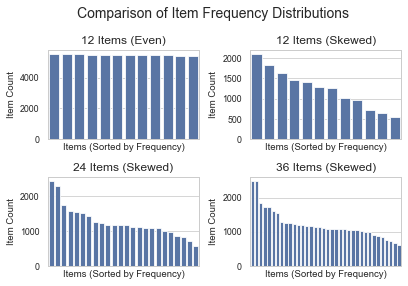

In [219]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style
sns.set_style("whitegrid") # 背景風格
sns.set_context("paper") # 元素大小

# --- Data Preparation ---
# This data remains the same
experiments = {
    '12 Items (Even)': {
        'counts': {'Milk': 5526, 'Ghee': 5510, 'Coffee Powder': 5509, 'Yougurt': 5503, 'Bread': 5484, 'Sweet': 5483, 'Sugar': 5482, 'Butter': 5481, 'Cheese': 5476, 'Panner': 5444, 'Lassi': 5432, 'Tea Powder': 5383},
        'total_txns': 12526
    },
    '12 Items (Skewed)': {
        'counts': {'1787583': 2091, '1787079': 1830, '21212': 1639, '22457': 1444, '998886': 1416, '435225': 1276, '470883': 1266, '477120': 1025, '1782459': 967, '1786029': 720, '1784937': 651, '1776516': 537},
        'total_txns': 5238
    },
    '24 Items (Skewed)': {
        'counts': {'1787079': 2452, '1787583': 2313, '21212': 1762, '998886': 1576, '22457': 1545, '435225': 1527, '470883': 1451, '470043': 1259, '435267': 1224, '470106': 1170, '466137': 1168, '477120': 1164, '460551': 1163, '470631': 1128, '435288': 1119, '487263': 1101, '1782459': 1096, '470022': 1081, '471849': 992, '482160': 971, '463806': 848, '1786029': 823, '1784937': 730, '1776516': 579},
        'total_txns': 7864
    },
    '36 Items (Skewed)': {
        'counts': {'1787079': 2492, '1787583': 2476, '21212': 1833, '470883': 1739, '998886': 1723, '22457': 1604, '435225': 1558, '470043': 1275, '477120': 1267, '435267': 1252, '466137': 1232, '1782459': 1205, '470106': 1188, '460551': 1170, '487263': 1170, '470631': 1148, '435288': 1136, '470022': 1107, '470064': 1087, '482181': 1076, '482160': 1073, '476679': 1065, '487389': 1065, '475986': 1061, '489258': 1049, '471849': 1039, '476637': 1009, '1732122': 979, '482853': 977, '463806': 907, '477267': 883, '1786029': 852, '1784937': 761, '1784370': 739, '316176': 658, '1776516': 601},
        'total_txns': 9677
    }
}

# --- Plotting ---
fig, axes = plt.subplots(2, 2) #figsize=(14, 10)
axes = axes.flatten()

for i, (title, data) in enumerate(experiments.items()):
    ax = axes[i]
    
    df = pd.DataFrame(list(data['counts'].items()), columns=['Item', 'Count'])
    df['Relative Frequency'] = df['Count'] / data['total_txns']
    df_sorted = df.sort_values(by='Relative Frequency', ascending=False)
    
    # --- THIS IS THE CORRECTED LINE ---
    # Plot the bar chart by passing the dataframe and column names
    # sns.barplot(data=df_sorted, x='Item', y='Relative Frequency', ax=ax, palette='mako')
    # "viridis", "plasma", "husl", "coolwarm", "Set1", "Set2", "Set3", rocket, mako, gray, 4C72B0, steelblue
    sns.barplot(
        data=df_sorted,
        x='Item',
        y='Count',           # CHANGED: Use the 'Count' column for the y-axis
        color='#4C72B0',   
        ax=ax
    )
    
    # Formatting for each subplot
    ax.set_title(title, fontsize=12)
    # ax.set_ylabel('Relative Frequency')
    ax.set_ylabel('Item Count') # Item Count (Frequency), Number of Items
    ax.set_xlabel('Items (Sorted by Frequency)')
    ax.set_xticks([]) # Hide x-tick labels to avoid clutter
    ax.tick_params(axis='x', bottom=False)

fig.suptitle('Comparison of Item Frequency Distributions', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.96, 1])
plt.savefig('./figures/dataset_analysis/items_frequency_distributions.png')

plt.show()

##### plot all

c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


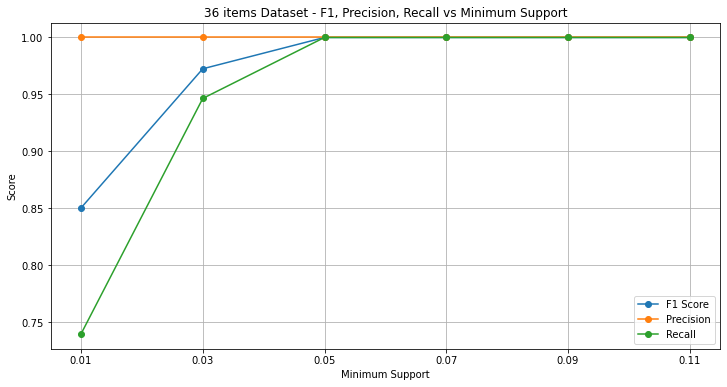

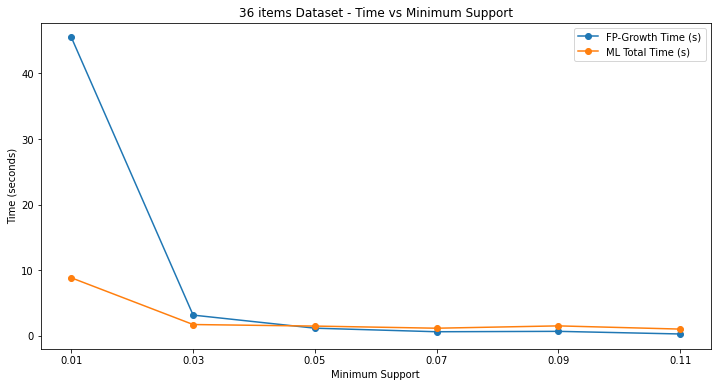

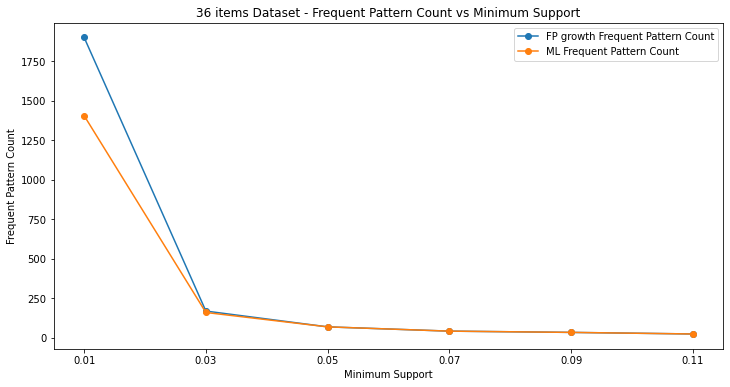

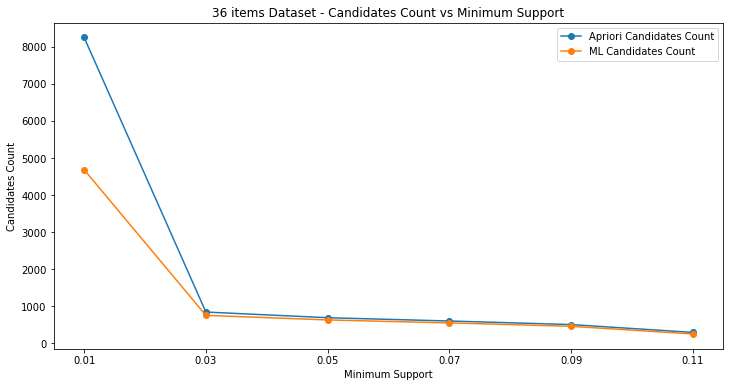

In [ ]:
# 繪製圖表
import matplotlib.pyplot as plt
def plot_all_plot(num_items, dataset_prct, note=''):
    # plt.figure(figsize=(12, 6))
    
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], f1_all, marker='o', label='F1 Score')
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], precision_all, marker='o', label='Precision')
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], recall_all, marker='o', label='Recall')
    plt.title(f'{num_items} items Dataset - F1, Precision, Recall vs Minimum Support') # {dataset_prct*100}%
    plt.xlabel('Minimum Support')
    plt.ylabel('Score')
    plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
    plt.legend()
    plt.grid()
    plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}{note}_score.png')
    plt.show()

    # draw time
    # plt.figure(figsize=(12, 6))
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], fpg_times, marker='o', label='FP-Growth Time (s)')
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], ml_total_times, marker='o', label='ML Total Time (s)')
    # plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], aprior_times, marker='o', label='Apriori Time (s)')
    plt.title(f'{num_items} items Dataset - Time vs Minimum Support') # {dataset_prct*100}%
    plt.xlabel('Minimum Support')
    plt.ylabel('Time (seconds)')
    plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
    plt.legend()
    # plt.grid()
    plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}{note}_time.png')
    plt.show()

    # draw pattern count
    # plt.figure(figsize=(12, 6))
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], pattern_count_all, marker='o', label='FP growth Frequent Pattern Count')
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], pattern_count_all_ml, marker='o', label='ML Frequent Pattern Count')
    plt.title(f'{num_items} items Dataset - Frequent Pattern Count vs Minimum Support') # {dataset_prct*100}%
    plt.xlabel('Minimum Support')
    plt.ylabel('Frequent Pattern Count')
    plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
    plt.legend()
    # plt.grid()
    plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}{note}_count.png')
    plt.show()

    # draw candidates count
    # plt.figure(figsize=(12, 6))
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], len_apriori_candidates, marker='o', label='Apriori Candidates Count')
    plt.plot([0.11, 0.09, 0.07, 0.05, 0.03, 0.01], len_ml_candidates, marker='o', label='ML Candidates Count')
    plt.title(f'{num_items} items Dataset - Candidates Count vs Minimum Support') # {dataset_prct*100}%
    plt.xlabel('Minimum Support')
    plt.ylabel('Candidates Count')
    plt.xticks([0.11, 0.09, 0.07, 0.05, 0.03, 0.01])
    plt.legend()
    # plt.grid()
    plt.savefig(f'./figures/{num_items}_items_dataset_{dataset_prct*100}{note}_candidates.png')
    plt.show()

# num_items = "12 even" # 或 "12 skewed", "24 skewed", "36 skewed"
# mynote = ''
# mynote='_order'
# mynote = "_thershold_1e-5_prun" # 只顯示 threshold
mynote = "_thershold_0.01_prun" #1e-5" # 顯示 threshold


plot_all_plot(num_items, dataset_prct, note=mynote) # 不加 note

### manual plot

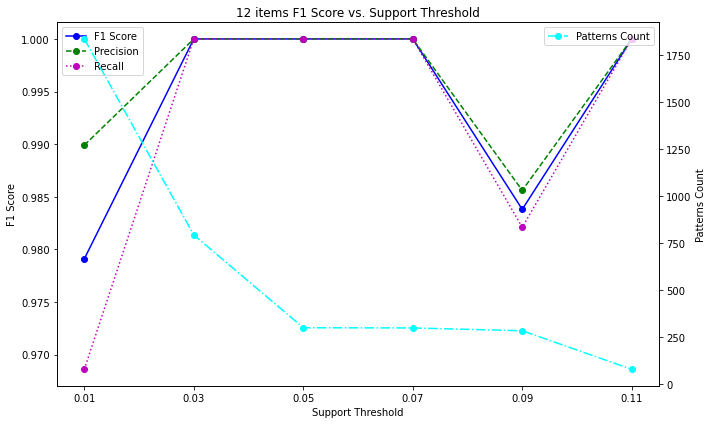

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# # 36 items F1 Score vs. Support Threshold
# support = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]

# precision = [0.9673, 0.9688, 0.9524, 0.9268, 0.9643, 0.9565]  # 假設的精確率
# recall = [0.9384,  0.9688, 1.0, 1.0, 1.0, 1.0]  # 假設的召回率
# f1_scores = [0.9526,  0.9688, 0.9756, 0.9620, 0.9818, 0.9778]  # 假設的 F1 分數

# patterns_counts = [1039, 160, 63, 41, 28, 23]  # 假設的樣式數量

# 12 items F1 Score vs. Support Threshold
support = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11]

precision = [0.9899, 1.0, 1.0, 1.0, 0.9856, 1.0]  # 假設的精確率
recall = [0.9686,  1.0, 1.0, 1.0, 0.9821, 1.0]  # 假設的召回率
f1_scores = [0.9791,  1.0, 1.0, 1.0, 0.9838, 1.0]  # 假設的 F1 分數

patterns_counts = [1836, 793, 299, 298, 283, 78]  # 假設的樣式數量

plt.figure(figsize=(10, 6))
# plt.plot(support, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
# plt.plot(support, patterns_counts, marker='o', linestyle='-', color='r', label='Patterns Count')
# plt.plot(support, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
# y 同時有f1分數和patterns數量
plt.plot(support, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
# plt.plot(support_thresholds, patterns_counts, marker='o', linestyle='-', color='r', label='Patterns Count')
plt.plot(support, precision, marker='o', linestyle='--', color='g', label='Precision')
plt.plot(support, recall, marker='o', linestyle=':', color='m', label='Recall')
plt.legend()
plt.xlabel('Support Threshold')
plt.ylabel('F1 Score')
plt.xticks(support)
# plt.yticks(np.arange(0.6, 0.9, 0.02))
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.title('36 items F1 Score vs. Support Threshold')
plt.title('12 items F1 Score vs. Support Threshold')

# plot patterns counts
plt.twinx()  # 使用雙 y 軸
plt.ylabel('Patterns Count')
plt.plot(support, patterns_counts, marker='o', linestyle='-.', color='cyan', label='Patterns Count')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### compare - 給定prefix

In [115]:
# 定義想查詢的prefix
# 使用 frozenset 來匹配 itemsets
prefix_to_find = frozenset(['Milk', 'Ghee'])

# 篩選
mask = fp_results['itemsets'].apply(lambda x: x.issuperset(prefix_to_find))
filtered_fp_results = fp_results[mask]

print(f"\n--- FP-Growth patterns containing {list(prefix_to_find)} ---")
# print(filtered_fp_results.sort_values(by="support", ascending=False))

print(len(filtered_fp_results), "patterns found with prefix", list(prefix_to_find))

# count by length
# print("\n--- Count by Length of Filtered Patterns ---")
filtered_fp_results['length'] = filtered_fp_results['itemsets'].apply(lambda x: len(x))
filtered_length_counts = filtered_fp_results['length'].value_counts().sort_index()
print(filtered_length_counts)


# ML 方法生成候選樣式的程式碼
print(f"\n--- ML Method Patterns with Prefix {list(prefix_to_find)} ---")
ml_prefix_results = generate_candidate_patterns(
    beam_width=150, #120 #50, #20,
    max_length=6,
    # start_with_prefix=['Milk', 'Ghee']
    # start_with_prefix=['Ghee', 'Milk']
    start_with_prefix=list(prefix_to_find)
)
# print(ml_prefix_results)
# ml_prefix_results 進行驗證
MIN_SUPPORT = 0.01
ml_prefix_results = validate_patterns(ml_prefix_results, min_support_count=MIN_SUPPORT)
# print(len(ml_prefix_results))


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-115-8aa182dda504>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_fp_results['length'] = filtered_fp_results['itemsets'].apply(lambda x: len(x))



--- FP-Growth patterns containing ['Ghee', 'Milk'] ---
220 patterns found with prefix ['Ghee', 'Milk']
length
2      1
3     10
4     45
5    120
6     44
Name: count, dtype: int64

--- ML Method Patterns with Prefix ['Ghee', 'Milk'] ---
Starting generation with a specific prefix: ['Ghee', 'Milk']
Starting generation with beam_width=150, generating up to 4 new items

--- Validating Candidate Patterns ---
Found 206 frequent patterns with support >= 0.01 in 10020 transactions.
Validation ratio: 63.19%: 206/326
Length 2: 1/1 = 100.00%
Length 3: 10/10 = 100.00%
Length 4: 45/45 = 100.00%
Length 5: 120/120 = 100.00%
Length 6: 30/150 = 20.00%


In [116]:
# ML結果與 FP-Growth 的篩選結果進行比較
print("\n--- Comparing ML Method Patterns with FP-Growth Filtered Patterns ---")
# 計算 ML 方法與 FP-Growth 篩選結果的交集
# print(len(ml_prefix_results))
ml_set = set(tuple(sorted(p)) for p in ml_prefix_results)
fp_set = set(tuple(sorted(p)) for p in filtered_fp_results['itemsets'])

intersection = ml_set.intersection(fp_set)
print(f"common patterns: {len(intersection)}")
#TP, FP, FN, TN
# print(len(ml_set), "ML patterns")
TP = len(intersection)
FP = len(ml_set) - TP
FN = len(fp_set) - TP
print(f"TP: {TP}, FP: {FP}, FN: {FN}")

# precision, recall, f1_score
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
print(f"Precision: {precision:.4f}, \nRecall: {recall:.4f}, \nF1 Score: {f1_score:.4f}")

# 按長度統計交集
intersection_lengths = [len(p) for p in intersection]
intersection_length_counts = Counter(intersection_lengths)
print("\n--- Intersection Length Counts ---")   
# sort by length
intersection_length_counts = dict(sorted(intersection_length_counts.items()))
for length, count in intersection_length_counts.items():
    print(f"Length {length}: {count} patterns")



--- Comparing ML Method Patterns with FP-Growth Filtered Patterns ---
common patterns: 206
TP: 206, FP: 0, FN: 14
Precision: 1.0000, 
Recall: 0.9364, 
F1 Score: 0.9671

--- Intersection Length Counts ---
Length 2: 1 patterns
Length 3: 10 patterns
Length 4: 45 patterns
Length 5: 120 patterns
Length 6: 30 patterns


c:\Users\zoezo\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
